<a href="https://colab.research.google.com/github/tpedCode/P05/blob/main/BARRET_Marjorie_2_notebook_modelisation_202604.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/content/drive/My Drive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P06

# **Openclassroom - Parcours Data Scientist**
# **Projet 6 - Classifier automatiquement des biens de consommation**

### **Environnement**

In [ ]:
# LIBRAIRIES STANDARD
import os
import json
import random
import shutil

# DATA MANIPULATION
import numpy as np
import pandas as pd

# VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# MACHINE LEARNING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

# DEEP LEARNING (TENSORFLOW / KERAS)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Modèle pré-entraîné
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# IMAGE PROCESSING
from PIL import Image

# SAUVEGARDE / SERIALISATION
import joblib

In [ ]:
# Définition du chemin de sauvegarde des datas processed
data_save_path = "/content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P06/data/processed/"
os.makedirs(data_save_path, exist_ok=True)

# **0. Préparation du dataset supervisé**

## **0.1 Chargement + vérifications**

In [ ]:
# Chargement du dataset préparé dans le notebook 1
df_images = pd.read_csv(os.path.join(data_save_path, "df_images.csv"))

In [ ]:
# Vérification structure de base
print("Shape :", df_images.shape)
print("\nColonnes :", df_images.columns.tolist())

display(df_images.head())

Shape : (1050, 3)

Colonnes : ['uniq_id', 'image_path', 'label']


,uniq_id,image_path,label
0,55b85ea15a1536d46b7190ad6fff8ce7,/content/drive/MyDrive/Pro/Data_Scientist_by_O...,Home Furnishing
1,7b72c92c2f6c40268628ec5f14c6d590,/content/drive/MyDrive/Pro/Data_Scientist_by_O...,Baby Care
2,64d5d4a258243731dc7bbb1eef49ad74,/content/drive/MyDrive/Pro/Data_Scientist_by_O...,Baby Care
3,d4684dcdc759dd9cdf41504698d737d8,/content/drive/MyDrive/Pro/Data_Scientist_by_O...,Home Furnishing
4,6325b6870c54cd47be6ebfbffa620ec7,/content/drive/MyDrive/Pro/Data_Scientist_by_O...,Home Furnishing


In [ ]:
# Vérifier que les images existent réellement
test_path = df_images["image_path"].iloc[0]
print("Exemple path :", test_path)
print("Existe :", os.path.exists(test_path))

# taux de chemins valides
valid_mask = df_images["image_path"].apply(os.path.exists)

print("\nImages valides :", valid_mask.sum())
print("Images manquantes :", (~valid_mask).sum())

Exemple path : /content/drive/MyDrive/Pro/Data_Scientist_by_Openclassrooms_en_cours/P06/data/raw/Images/55b85ea15a1536d46b7190ad6fff8ce7.jpg
Existe : True

Images valides : 1050
Images manquantes : 0


## **0.2 Encodage des labels**

In [ ]:
# Encodage des classes
label_encoder = LabelEncoder()
df_images["label_encoded"] = label_encoder.fit_transform(df_images["label"])

# mapping pour interprétation future
class_mapping = dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
))

In [ ]:
print("Nombre de classes :", len(label_encoder.classes_))
print("\nExemple mapping :", list(class_mapping.items())[:10])

Nombre de classes : 7

Exemple mapping : [('Baby Care', np.int64(0)), ('Beauty and Personal Care', np.int64(1)), ('Computers', np.int64(2)), ('Home Decor & Festive Needs', np.int64(3)), ('Home Furnishing', np.int64(4)), ('Kitchen & Dining', np.int64(5)), ('Watches', np.int64(6))]


In [ ]:
df_images[["label", "label_encoded"]].head()

,label,label_encoded
0,Home Furnishing,4
1,Baby Care,0
2,Baby Care,0
3,Home Furnishing,4
4,Home Furnishing,4


# **1. Split du dataset**

Cette partie découpe un dataset (df_images) en trois sous‑ensembles : entraînement (70%), validation (15%) et test (15%), tout en gardant la même distribution des classes (grâce à stratify).

In [ ]:
# # Split train / temp (85%)
# train_df, temp_df = train_test_split(
#     df_images,
#     test_size=0.30,
#     stratify=df_images["label_encoded"],
#     random_state=42
# )

In [ ]:
# # Split validation / test (50% du reste)
# val_df, test_df = train_test_split(
#     temp_df,
#     test_size=0.50,
#     stratify=temp_df["label_encoded"],
#     random_state=42
# )

In [ ]:
# LOAD
train_df = pd.read_csv(os.path.join(data_save_path, "train_df.csv"))
val_df = pd.read_csv(os.path.join(data_save_path, "val_df.csv"))
test_df = pd.read_csv(os.path.join(data_save_path, "test_df.csv"))

In [ ]:
# Vérification des tailles
print("Train shape :", train_df.shape)
print("Validation shape :", val_df.shape)
print("Test shape :", test_df.shape)

Train shape : (735, 4)
Validation shape : (157, 4)
Test shape : (158, 4)


In [ ]:
print("\nDistribution TRAIN :")
print(train_df["label_encoded"].value_counts(normalize=True))

print("\nDistribution VAL :")
print(val_df["label_encoded"].value_counts(normalize=True))

print("\nDistribution TEST :")
print(test_df["label_encoded"].value_counts(normalize=True))


Distribution TRAIN :
label_encoded
3    0.142857
5    0.142857
1    0.142857
2    0.142857
6    0.142857
4    0.142857
0    0.142857
Name: proportion, dtype: float64

Distribution VAL :
label_encoded
5    0.146497
0    0.146497
1    0.146497
2    0.140127
3    0.140127
4    0.140127
6    0.140127
Name: proportion, dtype: float64

Distribution TEST :
label_encoded
6    0.145570
4    0.145570
2    0.145570
3    0.145570
5    0.139241
1    0.139241
0    0.139241
Name: proportion, dtype: float64


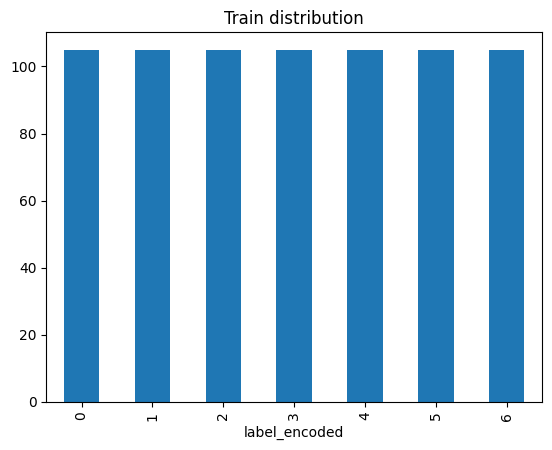

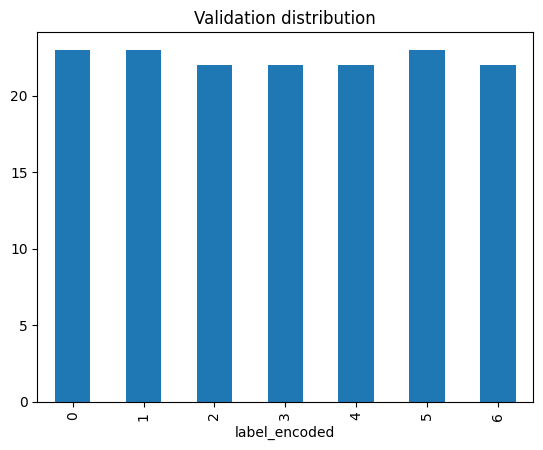

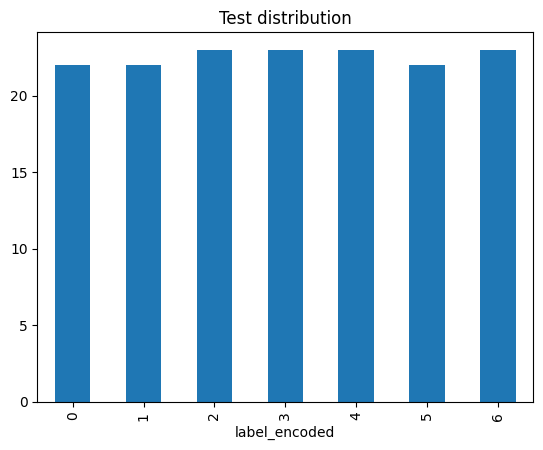

In [ ]:
train_df["label_encoded"].value_counts().sort_index().plot(kind="bar")
plt.title("Train distribution")
plt.show()

val_df["label_encoded"].value_counts().sort_index().plot(kind="bar")
plt.title("Validation distribution")
plt.show()

test_df["label_encoded"].value_counts().sort_index().plot(kind="bar")
plt.title("Test distribution")
plt.show()

# **2. Pipeline de chargement des images**

In [ ]:
# Définition de la taille des images et du nb traité à chaque idération
config_gen = {
    "img_size": [224, 224],
    "batch_size": 32
}

# Extraction des paramètres
img_size = tuple(config_gen["img_size"])
batch_size = config_gen["batch_size"]

In [ ]:
# Générateur d’images sans rescaling (préprocessing géré par VGG16)
datagen = ImageDataGenerator()

In [ ]:
def create_generator(df):
    """
    Crée un générateur d’images Keras à partir d’un DataFrame.
    Il charge les images à la volée depuis les chemins fournis et les prépare sous forme de batches utilisables par un modèle de deep learning.
    """

    return datagen.flow_from_dataframe(
        dataframe=df,
        x_col="image_path",       # chemin des images
        y_col="label_encoded",    # labels déjà encodés
        target_size=img_size,     # redimensionnement (ex: 224x224)
        batch_size=batch_size,    # taille des batches
        class_mode="raw",         # labels numériques (pas de one-hot)
        shuffle=True,             # mélange des données
        seed=42                   # reproductibilité
    )

In [ ]:
# Création des générateurs
train_generator = create_generator(train_df)
val_generator = create_generator(val_df)
test_generator = create_generator(test_df)

Found 735 validated image filenames.
Found 157 validated image filenames.
Found 158 validated image filenames.


In [ ]:
# Vérification
x_batch, y_batch = next(train_generator)

print("Shape images batch :", x_batch.shape)
print("Shape labels batch :", y_batch.shape)
print("Exemple labels :", y_batch[:10])

Shape images batch : (32, 224, 224, 3)
Shape labels batch : (32,)
Exemple labels : [1 6 5 2 3 2 5 3 4 0]


# **4. Classification supervisée et stratégies de data augmentation**


Cette section introduit les différentes stratégies expérimentales mises en place afin d’évaluer l’impact du traitement des données sur les performances d’un modèle de classification supervisée.

L’objectif est de comparer plusieurs approches reposant sur des pipelines de chargement et des techniques de data augmentation distinctes, tout en conservant une architecture de modèle identique. Cela permet d’isoler précisément l’effet des variations de données sur la qualité de l’apprentissage.

Concrètement, quatre configurations sont implémentées : une baseline utilisant les images brutes, une approche avec augmentation dynamique via ImageDataGenerator (rotations, translations, zooms, etc.), une approche basée sur un pipeline tf.data optimisé pour le chargement des images, et enfin une approche intégrant directement les transformations dans le modèle. Chaque configuration prépare différemment les données qui seront ensuite utilisées pour entraîner le même modèle.

Cette démarche s’inscrit dans une logique expérimentale rigoureuse visant à comprendre les leviers d’amélioration de la généralisation, en particulier dans un contexte de dataset de taille limitée.

## **4.0. Création du modèle de classification commun**

#### **Objectif**

Cette section vise à définir une architecture de classification d’images basée sur le transfert d’apprentissage, utilisée comme modèle commun pour l’ensemble des expérimentations.

Les objectifs sont :

* exploiter un modèle pré-entraîné pour extraire des caractéristiques visuelles pertinentes,
* adapter ce modèle au problème de classification étudié,
* construire une architecture complète et réutilisable,
* garantir une base commune à toutes les approches expérimentales.

#### **Concepts data clés**

* **Transfer learning** : réutilisation d’un modèle entraîné sur un large dataset pour une nouvelle tâche.

* **Modèle pré-entraîné (VGG16)** : réseau ayant appris des représentations visuelles sur ImageNet.

* **Feature extraction** : utilisation du modèle comme extracteur de caractéristiques sans modifier ses poids.

* **Tête de classification** : couches ajoutées pour adapter la sortie au nombre de classes.

* **Préprocessing spécifique** : normalisation des images adaptée au modèle utilisé.

#### **Justification des choix méthodologiques**

* L’utilisation de VGG16 :
  * permet de bénéficier de représentations visuelles robustes,
  * améliore la convergence avec peu de données.

* Le gel des couches convolutionnelles :
  * conserve les caractéristiques générales apprises,
  * limite le sur-apprentissage.

* L’intégration du preprocessing (`preprocess_input`) :
  * garantit la compatibilité avec ImageNet,
  * améliore les performances.

* L’utilisation de GlobalAveragePooling :
  * réduit significativement le nombre de paramètres,
  * limite le sur-apprentissage.

* L’ajout de couches Dense avec Dropout :
  * permet d’adapter le modèle à la tâche,
  * renforce la capacité de généralisation.

#### **Lecture globale de la section**

* Cette étape définit l’architecture commune du modèle,
* elle garantit la cohérence des expérimentations,
* elle permet d’isoler l’impact des pipelines de données.

In [ ]:
# Paramètres globaux
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
RANDOM_STATE = 42

# Nombre de classes
N_CLASSES = train_df["label_encoded"].nunique()
print("Nombre de classes :", N_CLASSES)

Nombre de classes : 7


In [ ]:
# Chargement du modèle CNN pré‑entraîné (VGG16)
def get_vgg16_base(input_shape=(224, 224, 3)):
    """
    Charge VGG16 sans la tête de classification et gèle ses poids.
    """

    base_model = VGG16(
        weights="imagenet",        # utilise des features déjà apprises (contours, textures…)
        include_top=False,         # enlève la classification pour l’adapter à notre problème
        input_shape=input_shape    # impose le format d’entrée attendu
    )

    base_model.trainable = False  # on bloque l'entraînement → on garde les connaissances apprises (pas de modif des poids)

    return base_model

In [ ]:
# Fonction de création du modèle de classification
def create_base_model(n_classes, input_shape=(224, 224, 3), augmentation_layer=None):
    """
    Crée un modèle de classification basé sur VGG16 (transfer learning).
    """

    # =========================
    # BACKBONE VGG16
    # =========================
    base_model = get_vgg16_base(input_shape)
    # → modèle pré-entraîné sur ImageNet
    # → il sait déjà détecter des éléments visuels (contours, textures, formes…)
    # → il est gelé ⇒ il ne s'adapte pas au dataset actuel

    model_layers = []

    # =========================
    # DATA AUGMENTATION (OPTIONNEL)
    # =========================
    if augmentation_layer is not None:
        model_layers.append(augmentation_layer)
        # → modifie légèrement les images (rotation, zoom…)
        # → permet d’éviter que le modèle apprenne "par cœur"
        # → aide à mieux généraliser

    # =========================
    # PRÉPROCESSING
    # =========================
    model_layers.append(layers.Lambda(preprocess_input))
    # → transforme les pixels pour correspondre à ce que VGG16 attend
    # → indispensable sinon les features extraites sont mauvaises

    # =========================
    # FEATURE EXTRACTION
    # =========================
    model_layers.append(base_model)
    # → transforme l’image (224x224x3)
    # → en représentation (7x7x512)
    # → 7x7 = zones de l’image
    # → 512 = types de features détectées (formes, motifs…)

    # =========================
    # TÊTE DE CLASSIFICATION
    # =========================
    model_layers.extend([

        layers.GlobalAveragePooling2D(),
        # → transforme 7x7x512 → 512
        # → moyenne chaque feature sur toute l’image
        # → résultat = résumé global de l’image

        layers.Dense(256, activation="relu"),
        # → transforme les 512 features en 256 nouvelles
        # → apprend quelles combinaisons de features sont utiles
        # → c’est ici que le modèle s’adapte au problème actuel (classes spécifiques)
        # ⚠️ ce n’est pas encore la décision finale

        layers.Dropout(0.5),
        # → désactive aléatoirement 50% des neurones
        # → évite le surapprentissage (le modèle ne peut pas mémoriser)

        layers.Dense(n_classes, activation="softmax")
        # → transforme les 256 features en n_classes scores
        # → softmax convertit en probabilités (somme = 1)
        # → ex : [0.8, 0.1, 0.05, ...]
        # → c’est ici que la classe finale est déterminée
    ])

    # =========================
    # CONSTRUCTION
    # =========================
    model = models.Sequential(model_layers)
    # → modèle = enchaînement des étapes dans l’ordre

    # =========================
    # COMPILATION
    # =========================
    model.compile(
        optimizer="adam",
        # → ajuste les poids de Dense automatiquement
        # → plus rapide et stable que SGD classique

        loss="sparse_categorical_crossentropy",
        # → mesure l’écart entre prédiction et vraie classe
        # → adapté car labels = entiers (0,1,2,…)

        metrics=["accuracy"]
        # → pourcentage de bonnes prédictions
    )

    return model

In [ ]:
# Test rapide du modèle
model_test = create_base_model(
    n_classes=N_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

model_test.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Test d'un forward pass (construction effective du modèle)
dummy_input = np.random.random((1, 224, 224, 3))

output = model_test.predict(dummy_input)

print("Shape sortie :", output.shape)
print("Somme des probabilités :", output.sum())
print("Probabilités :", output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Shape sortie : (1, 7)
Somme des probabilités : 1.0
Probabilités : [[0.04256404 0.008117   0.21841508 0.33835086 0.01453133 0.10167449
  0.2763472 ]]


## **4.1. Approche 1 — Préparation initiale des images (baseline)**

#### **Objectif**

Cette approche vise à établir une référence minimale de performance en entraînant le modèle sur les données brutes.

Les objectifs sont :

* évaluer la capacité d’apprentissage sans enrichissement,
* observer le sur-apprentissage,
* fournir un point de comparaison pour les autres approches.

#### **Concepts data clés**

* **Baseline** : modèle de référence servant de point de comparaison.

* **Absence de data augmentation** : les images sont utilisées telles quelles.

* **Généralisation** : capacité du modèle à performer sur des données nouvelles.

#### **Justification des choix méthodologiques**

* L’absence de data augmentation :
  * permet d’évaluer la difficulté intrinsèque du problème,
  * met en évidence les limites du dataset.

* L’utilisation d’ImageDataGenerator sans transformation :
  * pipeline simple et reproductible,
  * cohérent avec les autres approches.

* L’architecture du modèle reste inchangée :
  * garantit une comparaison équitable.

#### **Lecture globale de la section**

* Cette approche fournit une référence minimale,
* elle met en évidence les limites du modèle sans enrichissement,
* elle sert de base à l’ensemble des comparaisons.

→ Elle constitue le point de départ du protocole expérimental.

In [ ]:
# Générateur sans data augmentation
datagen_baseline = ImageDataGenerator()

In [ ]:
# Fonction de création des générateurs TRAIN / VAL / TEST
def create_baseline_generator(df, shuffle):
    return datagen_baseline.flow_from_dataframe(
        dataframe=df,
        x_col="image_path",
        y_col="label_encoded",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="raw",
        shuffle=shuffle,
        seed=RANDOM_STATE
    )

In [ ]:
# Création des générateurs TRAIN / VAL / TEST
train_generator_baseline = create_baseline_generator(
    train_df, shuffle=True
)

val_generator_baseline = create_baseline_generator(
    val_df, shuffle=False
)

test_generator_baseline = create_baseline_generator(
    test_df, shuffle=False
)

Found 735 validated image filenames.
Found 157 validated image filenames.
Found 158 validated image filenames.


In [ ]:
# Création du modèle baseline

model_baseline = create_base_model(
    n_classes=N_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    augmentation_layer=None
)

In [ ]:
# Vérification du modèle
model_baseline.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## **4.2. Approche 2 — Génération dynamique des images avec ImageDataGenerator**

#### **Objectif**

Cette approche vise à améliorer la généralisation du modèle en introduisant de la variabilité artificielle dans les données d’entraînement.

Les objectifs sont :

* enrichir le dataset sans collecter de nouvelles données,
* réduire le sur-apprentissage,
* améliorer les performances sur les données de test.

#### **Concepts data clés**

* **Data augmentation** : génération de nouvelles données à partir de transformations.

* **Génération dynamique** : création des images à la volée lors de l’entraînement.

* **Transformations géométriques** : rotation, translation, zoom, symétrie.

#### **Justification des choix méthodologiques**

* L’utilisation d’ImageDataGenerator :
  * permet l’augmentation en temps réel,
  * évite la duplication des données.

* Les transformations choisies :
  * simulent des variations réalistes,
  * augmentent la diversité du dataset.

* L’augmentation uniquement sur le train :
  * garantit une évaluation fiable,
  * évite toute fuite de données.

* L’architecture du modèle reste identique :
  * permet d’isoler l’impact de la data augmentation.

#### **Lecture globale de la section**

* Cette approche améliore la robustesse du modèle,
* elle limite le sur-apprentissage,
* elle augmente la capacité de généralisation.

→ Elle constitue une amélioration directe de la baseline.

In [ ]:
# Générateur avec data augmentation (TRAIN uniquement)
datagen_train = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [ ]:
# Générateur sans data augmentation pour validation et test
datagen_noaug = ImageDataGenerator()

In [ ]:
# Fonction de création des générateurs TRAIN / VAL / TEST
def create_aug_generator(df, datagen, shuffle):
    return datagen.flow_from_dataframe(
        dataframe=df,
        x_col="image_path",
        y_col="label_encoded",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="raw",
        shuffle=shuffle,
        seed=RANDOM_STATE
    )

In [ ]:
# Création des générateurs TRAIN / VAL / TEST
train_generator_aug = create_aug_generator(
    train_df, datagen_train, shuffle=True
)

val_generator_aug = create_aug_generator(
    val_df, datagen_noaug, shuffle=False
)

test_generator_aug = create_aug_generator(
    test_df, datagen_noaug, shuffle=False
)

Found 735 validated image filenames.
Found 157 validated image filenames.
Found 158 validated image filenames.


In [ ]:
# Création du modèle associé à l’approche ImageDataGenerator
model_datagen_aug = create_base_model(
    n_classes=N_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    augmentation_layer=None
)

In [ ]:
# Vérification
model_datagen_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## **4.3. Approche 3 — Pipeline sans data augmentation (référence méthodologique)**

#### **Objectif**

Cette approche vise à évaluer l’impact du pipeline de chargement des données indépendamment de toute augmentation.

Les objectifs sont :

* comparer deux pipelines (ImageDataGenerator vs tf.data),
* analyser l’impact du chargement des données,
* améliorer la performance globale du système.

#### **Concepts data clés**

* **tf.data.Dataset** : pipeline TensorFlow optimisé pour le chargement des données.

* **Pipeline data** : chaîne de traitement des données avant l’entraînement.

* **Batching / Prefetch** : optimisation du flux de données vers le modèle.

#### **Justification des choix méthodologiques**

* L’utilisation de `image_dataset_from_directory` :
  * offre un pipeline natif et optimisé,
  * améliore la gestion du chargement des données.

* L’absence de data augmentation :
  * permet une comparaison directe avec la baseline.

* Le modèle utilisé est identique à celui défini en section 4.0 :
  * garantit une comparaison équitable,
  * isole uniquement l’impact du pipeline.

#### **Lecture globale de la section**

* Cette approche met en évidence l’impact du pipeline de données,
* elle améliore la stabilité et les performances,
* elle permet d’optimiser le flux d’entraînement.

→ Elle isole l’effet de l’infrastructure de données sur le modèle.

In [ ]:
# Définition des chemins Dataset
DATASET_DIR = os.path.join(data_save_path, "dataset")

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

# Crée uniquement si nécessaire (sans écraser l’existant)
os.makedirs(DATASET_DIR, exist_ok=True)


In [ ]:
# Fonction de création de la structure Dataset
def create_dataset_directory(df, base_dir):
    """
    Crée une arborescence compatible avec image_dataset_from_directory
    à partir d'un DataFrame contenant les chemins d'images et les labels.
    """
    os.makedirs(base_dir, exist_ok=True)

    for _, row in df.iterrows():
        label = str(row["label_encoded"])
        src_path = row["image_path"]

        label_dir = os.path.join(base_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        dst_path = os.path.join(label_dir, os.path.basename(src_path))

        if not os.path.exists(dst_path):
            shutil.copy(src_path, dst_path)

In [ ]:
# # L'API tf.data.Dataset nécessite une arborescence par classes.
# if not os.path.exists(TRAIN_DIR) or len(os.listdir(TRAIN_DIR)) == 0:
#     create_dataset_directory(train_df, TRAIN_DIR)
#     create_dataset_directory(val_df, VAL_DIR)
#     create_dataset_directory(test_df, TEST_DIR)

In [ ]:
# # Création des objets Dataset TensorFlow
# dataset_train = tf.keras.utils.image_dataset_from_directory(
#     TRAIN_DIR,
#     labels="inferred",
#     label_mode="int",
#     batch_size=BATCH_SIZE,
#     image_size=IMG_SIZE,
#     shuffle=True,
#     seed=RANDOM_STATE
# )

# dataset_val = tf.keras.utils.image_dataset_from_directory(
#     VAL_DIR,
#     labels="inferred",
#     label_mode="int",
#     batch_size=BATCH_SIZE,
#     image_size=IMG_SIZE,
#     shuffle=False
# )

# dataset_test = tf.keras.utils.image_dataset_from_directory(
#     TEST_DIR,
#     labels="inferred",
#     label_mode="int",
#     batch_size=BATCH_SIZE,
#     image_size=IMG_SIZE,
#     shuffle=False
# )

In [ ]:
# Création du modèle associé à l’approche Dataset
model_dataset_noaug = create_base_model(
    n_classes=N_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    augmentation_layer=None
)

In [ ]:
# Vérification du modèle
model_dataset_noaug.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## **4.4. Approche 4 — Data augmentation intégrée directement au modèle**

#### **Objectif**

Cette approche vise à intégrer directement la data augmentation dans le modèle afin de simplifier le pipeline et améliorer la reproductibilité.

Les objectifs sont :

* simplifier le pipeline de données,
* améliorer la reproductibilité,
* tester une approche moderne de preprocessing.

#### **Concepts data clés**

* **Data augmentation intégrée** : transformations incluses dans le modèle.

* **Couches Keras de preprocessing** : RandomFlip, RandomRotation, RandomZoom.

* **Pipeline intégré** : traitement des données directement dans le modèle.

#### **Justification des choix méthodologiques**

* L’utilisation des couches Keras :
  * permet une intégration native dans le modèle,
  * active les transformations uniquement pendant l’entraînement.

* La simplification du pipeline :
  * réduit la dépendance au preprocessing externe,
  * améliore la lisibilité et la portabilité.

* Le maintien du même modèle :
  * permet une comparaison cohérente avec les autres approches.

#### **Lecture globale de la section**

* Cette approche modernise le pipeline de traitement,
* elle améliore la reproductibilité,
* elle conserve de bonnes performances.

→ Elle constitue une version plus intégrée et industrialisable du pipeline.

In [ ]:
# Bloc de data augmentation intégré au modèle
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation"
)

In [ ]:
# Générateurs / datasets SANS augmentation
datagen_noaug = ImageDataGenerator()

In [ ]:
# Fonction de création des générateurs TRAIN / VAL / TEST
def create_noaug_generator(df, shuffle):
    return datagen_noaug.flow_from_dataframe(
        dataframe=df,
        x_col="image_path",
        y_col="label_encoded",
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="raw",
        shuffle=shuffle,
        seed=RANDOM_STATE
    )

In [ ]:
# Générateurs sans data augmentation (augmentation intégrée au modèle)
train_generator_model_aug = create_noaug_generator(
    train_df, shuffle=True
)

val_generator_model_aug = create_noaug_generator(
    val_df, shuffle=False
)

test_generator_model_aug = create_noaug_generator(
    test_df, shuffle=False
)

Found 735 validated image filenames.
Found 157 validated image filenames.
Found 158 validated image filenames.


In [ ]:
# Création du modèle
model_aug_in_model = create_base_model(
    n_classes=N_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    augmentation_layer=data_augmentation
)

In [ ]:
# Vérification
model_aug_in_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## **4.5. Synthèse des approches de classification supervisée**

### **4.5.1. Rappel des approches implémentées**

Approche 4.1 — Préparation baseline (sans data augmentation)
- Chargement dynamique des images via ImageDataGenerator
- Aucune data augmentation
- Sert de référence de performance

Approche 4.2 — ImageDataGenerator avec data augmentation
- Chargement dynamique avec ImageDataGenerator
- Data augmentation appliquée au niveau du générateur
- Augmentation uniquement sur l’ensemble d’entraînement

Approche 4.3 — Pipeline Dataset sans data augmentation
- Chargement des images via l’API tf.data.Dataset
- Organisation des images par répertoire de classes
- Aucune data augmentation
- Approche moderne centrée sur TensorFlow natif

Approche 4.4 — Data augmentation intégrée directement au modèle
- Chargement des images sans augmentation
- Data augmentation appliquée au sein du modèle
- Transformation active uniquement lors de l’entraînement
- Modèle final plus facilement déployable

| Approche | Pipeline d'entrée | Data augmentation | Aug uniquement sur TRAIN | Architecture commune |
|---------|-------------------|-------------------|--------------------------|----------------------|
| 4.1 Baseline | ImageDataGenerator | Non | Oui | Oui |
| 4.2 ImageDataGenerator + Aug | ImageDataGenerator | Oui (générateur) | Oui | Oui |
| 4.3 Dataset (sans aug) | tf.data.Dataset | Non | Oui | Oui |
| 4.4 Aug intégrée au modèle | ImageDataGenerator + modèle | Oui (dans le modèle) | Oui | Oui |

### **4.5.2. Hypothèses avant entraînement**

Avant l’entraînement des modèles, les hypothèses suivantes sont formulées :
- la data augmentation devrait améliorer la capacité de généralisation du modèle ;
- l’approche avec augmentation intégrée au modèle pourrait offrir une meilleure stabilité ;
- l’approche sans augmentation servira de référence pour mesurer l’impact réel des transformations ;
- les performances dépendront davantage du pipeline de données que de l’architecture, celle‑ci étant identique.

Les modèles associés à chacune de ces approches vont désormais être entraînés dans des conditions strictement identiques afin de permettre une comparaison équitable de leurs performances.

# **5. Entraînement des modèles**

Cette section met en œuvre l’entraînement effectif des différentes configurations définies précédemment, dans un cadre expérimental strict visant à garantir la comparabilité des résultats.

L’objectif est d’évaluer l’impact réel des différentes stratégies de data augmentation et de pipeline de données sur les performances du modèle, tout en maintenant constants les autres éléments du système (architecture, hyperparamètres principaux, procédures d’évaluation).

Concrètement, chaque modèle est entraîné séparément avec son propre pipeline de données (baseline, data augmentation, tf.data ou augmentation intégrée), en utilisant les mêmes paramètres d’entraînement. À chaque étape, les performances sont enregistrées (accuracy, loss), puis le modèle est évalué sur un jeu de test indépendant pour obtenir une mesure fiable de sa capacité de généralisation. Les prédictions sont également sauvegardées afin de permettre une analyse détaillée des erreurs.

Cette étape permet de quantifier de manière fiable les gains apportés par chaque approche et de préparer une analyse comparative approfondie des résultats.

## **5.1 Approche 1 — Baseline sans data augmentation**

#### **Objectif**

Cette approche vise à établir une référence minimale sans enrichissement des données.

Les objectifs sont :

* mesurer la capacité du modèle brut,
* détecter le sur‑apprentissage,
* servir de point de comparaison.

#### **Concepts data clés**

* **Baseline** : modèle de référence simple servant de point de comparaison.

* **Overfitting (sur‑apprentissage)** : apprentissage excessif des données d’entraînement.

* **Généralisation** : capacité à performer sur de nouvelles données.

#### **Justification des choix méthodologiques**

* Absence de data augmentation :
  * permet d’observer le comportement “naturel” du modèle,
  * sert de référence neutre.

* Utilisation d’ImageDataGenerator sans transformation :
  * pipeline simple,
  * cohérent avec les autres approches.

* Même architecture VGG16 :
  * assure une comparaison équitable.

#### **Lecture globale de la section**

* Cette approche met en évidence :
  * la capacité d’apprentissage brute,
  * le sur‑apprentissage important,
  * les limites sans augmentation.

→ Elle sert de point de départ indispensable.

In [ ]:
# # Modèle
# model_baseline = create_base_model(
#     n_classes=N_CLASSES,
#     input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
#     augmentation_layer=None
# )

# model_baseline.summary()

In [ ]:
# # Callbacks + Entraînement
# baseline_model_path = os.path.join(
#     data_save_path,
#     "model_baseline_best_weights.h5"
# )

# callbacks_baseline = [
#     ModelCheckpoint(
#         baseline_model_path,
#         monitor="val_loss",
#         save_best_only=True,
#         mode="min"
#     ),
#     EarlyStopping(
#         monitor="val_loss",
#         patience=5,
#         restore_best_weights=True
#     )
# ]

# history_baseline = model_baseline.fit(
#     train_generator_baseline,
#     validation_data=val_generator_baseline,
#     epochs=50,
#     callbacks=callbacks_baseline,
#     verbose=1
# )

In [ ]:
# # Test

# # CORRECTION MAJEURE :
# # On reset le générateur AVANT toute prédiction
# # → garantit que les images sont lues dans le bon ordre
# # → évite un désalignement entre y_pred et y_true

# test_generator_baseline.reset()

# # Prédictions du modèle
# # → predict() lit les images dans l’ordre du générateur
# y_pred = np.argmax(
#     model_baseline.predict(test_generator_baseline, verbose=1),
#     axis=1
# )

# # Labels réels
# # → récupérés depuis le DataFrame (ordre fixe et fiable)
# y_true = test_df["label_encoded"].values

# # Évaluation du modèle
# # → mesure de la performance réelle
# # IMPORTANT : sans reset, evaluate() peut aussi être biaisé
# test_loss, test_acc = model_baseline.evaluate(
#     test_generator_baseline,
#     verbose=1
# )

# # Stockage des résultats
# test_results_baseline = {
#     "accuracy": test_acc,
#     "loss": test_loss,
#     "y_true": y_true,
#     "y_pred": y_pred,

#     # Matrice de confusion fiable (corrigée)
#     "confusion_matrix": confusion_matrix(y_true, y_pred),

#     # Rapport de classification fiable
#     "classification_report": classification_report(
#         y_true, y_pred,
#         output_dict=True
#     )
# }

**Correction critique du protocole d’évaluation**

Lors des premières expérimentations, la performance de la baseline était estimée à **\~12%**, soit proche du hasard.  
Cette valeur laissait penser que le modèle était inefficace.

**Origine du problème**

Cette anomalie provenait d’un **désalignement entre les prédictions (`y_pred`) et les labels réels (`y_true`)**.

Avec `ImageDataGenerator`, les données sont fournies via un générateur qui possède un **curseur interne**.  
Si ce générateur n’est pas réinitialisé, les images peuvent être lues dans un ordre différent de celui des labels.

**Problème typique :**

* Ordre des labels (`y_true`) : img1, img2, img3, img4
* Ordre des prédictions (`y_pred`) : img3, img4, img1, img2

Les prédictions sont correctes… mais comparées aux **mauvaises images**.

**Résultat :**

* erreurs artificielles
* accuracy très faible (\~12%)
* matrice de confusion incohérente

**Correction appliquée**

```python
test_generator_baseline.reset()
```

Cette instruction permet de :

* remettre le générateur au début
* garantir l’ordre correct des images
* aligner correctement `y_pred` et `y_true`

**Impact de la correction**

| Avant                   | Après              |
| ----------------------- | ------------------ |
| Accuracy ≈ 12%          | Accuracy ≈ 83%     |
| Résultats incohérents   | Résultats fiables  |
| Mauvaise interprétation | Performance réelle |

**Conclusion data science**

* Le modèle baseline était **déjà performant**
* Le problème venait **uniquement du protocole d’évaluation**
* La correction du `reset()` a permis de :
  * fiabiliser les métriques
  * révéler les performances réelles

> Cette correction illustre l’importance critique du contrôle des pipelines de données en data science.

In [ ]:
# # SAVE historique
# np.save(
#     os.path.join(data_save_path, "history_baseline.npy"),
#     history_baseline.history
# )

# # SAVE résultats test
# np.save(
#     os.path.join(data_save_path, "test_results_baseline.npy"),
#     test_results_baseline
# )

# print("Baseline sauvegardée")

In [ ]:
# LOAD

# Recréation du modèle
model_baseline = create_base_model(
    n_classes=N_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    augmentation_layer=None
)

# Build obligatoire
dummy = tf.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3))
_ = model_baseline(dummy)

# Chargement des poids
model_baseline.load_weights(
    os.path.join(data_save_path, "model_baseline_best_weights.h5")
)

# Chargement de l'historique
baseline_history = np.load(
    os.path.join(data_save_path, "history_baseline.npy"),
    allow_pickle=True
).item()

# Chargement des résultats test
test_results_baseline = np.load(
    os.path.join(data_save_path, "test_results_baseline.npy"),
    allow_pickle=True
).item()

print("Baseline complètement chargée")

acc = test_results_baseline["accuracy"]
loss = test_results_baseline["loss"]

print("\n=== Performances Test ===")
print(f"Accuracy : {acc:.4f}")
print(f"Loss     : {loss:.4f}")
model_baseline.summary()

Baseline complètement chargée

=== Performances Test ===
Accuracy : 0.8291
Loss     : 0.7570


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_5 (Lambda)               │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (1, 7, 7, 512)         │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (1, 512)               │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (1, 256)               │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (1, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (1, 7)                 │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

* **Baseline complètement chargée** : le modèle de base avec VGG16 pré-entraîné a été correctement chargé et prêt à être utilisé.

* **Accuracy : 0.8291** : le modèle classe correctement environ 83 % des images.

* **Loss : 0.7570** : l'erreur moyenne du modèle est modérée, indiquant que certaines prédictions restent incertaines.

* **Model: "sequential\_5"** : le modèle est une architecture séquentielle où les couches sont empilées les unes après les autres.

* **lambda\_5 (Lambda)** : cette couche applique un prétraitement (souvent normalisation des pixels) sans apprendre de paramètres.

* **Output Shape: (1, 224, 224, 3)** : les images en entrée font 224×224 pixels avec 3 canaux (RGB).

* **vgg16 (Functional)** : c’est un réseau de neurones convolutionnel pré-entraîné utilisé pour extraire des caractéristiques visuelles.

* **Output Shape: (1, 7, 7, 512)** : l’image est transformée en 512 cartes de caractéristiques compactées en taille 7×7.

* **Param #: 14,714,688** : VGG16 contient plus de 14 millions de paramètres appris sur ImageNet.

* **global\_average\_pooling2d\_5** : cette couche réduit chaque carte de caractéristiques à une seule valeur en faisant une moyenne.

* **Output Shape: (1, 512)** : les données sont compressées en un vecteur de 512 valeurs importantes.

* **dense\_10 (Dense)** : cette couche apprend à combiner les caractéristiques pour préparer la classification.

* **Output Shape: (1, 256)** : les 512 features sont transformées en 256 neurones.

* **dropout\_5 (Dropout)** : cette couche désactive aléatoirement des neurones pendant l’entraînement pour éviter le surapprentissage.

* **dense\_11 (Dense)** : c’est la couche finale qui produit les prédictions pour chaque classe.

* **Output Shape: (1, 7)** : le modèle donne un score pour chacune des 7 classes possibles.

* **Total params: 14,847,815** : le modèle complet contient environ 14,8 millions de paramètres.

* **Trainable params: 133,127** : seulement une petite partie (les couches finales) est réellement entraînée.

* **Non-trainable params: 14,714,688** : les poids de VGG16 sont gelés et ne sont pas modifiés pendant l’apprentissage.

**Résumé global** : VGG16 est utilisé comme extracteur de caractéristiques fixe, puis un petit réseau dense apprend à faire la classification sur les 7 classes.


## **5.2 Approche 2 — Data augmentation via ImageDataGenerator**

#### **Objectif**

Cette approche vise à améliorer la généralisation via une augmentation dynamique des données.

Les objectifs sont :

* enrichir le dataset,
* réduire le sur‑apprentissage,
* améliorer les performances test.

#### **Concepts data clés**

* **Data augmentation** : transformations appliquées aux données pour augmenter leur diversité.

* **ImageDataGenerator** : outil Keras générant des images augmentées à la volée.

* **Variabilité artificielle** : simulation de nouvelles conditions visuelles.

#### **Justification des choix méthodologiques**

* Transformations (rotation, shift, zoom, flip) :
  * augmentent la diversité,
  * simulent des conditions réelles.

* Augmentation uniquement sur le train :
  * garantit une évaluation fiable.

* Maintien du même modèle :
  * isole l’impact de la data augmentation.

#### **Lecture globale de la section**

* Cette approche :
  * améliore fortement la généralisation,
  * réduit le sur‑apprentissage,
  * montre l’importance de l’enrichissement des données.

→ Elle constitue une amélioration directe de la baseline.

In [ ]:
# # Générateur TRAIN avec data augmentation
# datagen_train = ImageDataGenerator(
#     rotation_range=15,
#     width_shift_range=0.1,
#     height_shift_range=0.1,
#     zoom_range=0.1,
#     horizontal_flip=True
# )

# # Générateur VAL / TEST sans augmentation
# datagen_noaug = ImageDataGenerator()

# def create_aug_generator(df, datagen, shuffle):
#     return datagen.flow_from_dataframe(
#         dataframe=df,
#         x_col="image_path",
#         y_col="label_encoded",
#         target_size=IMG_SIZE,
#         batch_size=BATCH_SIZE,
#         class_mode="raw",
#         shuffle=shuffle,
#         seed=RANDOM_STATE
#     )

# train_generator_datagen = create_aug_generator(train_df, datagen_train, True)
# val_generator_datagen   = create_aug_generator(val_df, datagen_noaug, False)
# test_generator_datagen  = create_aug_generator(test_df, datagen_noaug, False)

In [ ]:
# # Callbacks + Entraînement
# datagen_aug_model_path = os.path.join(
#     data_save_path,
#     "model_datagen_aug_best_weights.h5"
# )

# callbacks_datagen_aug = [
#     ModelCheckpoint(
#         datagen_aug_model_path,
#         monitor="val_loss",
#         save_best_only=True,
#         mode="min"
#     ),
#     EarlyStopping(
#         monitor="val_loss",
#         patience=5,
#         restore_best_weights=True
#     )
# ]

# history_datagen_aug = model_datagen_aug.fit(
#     train_generator_datagen,
#     validation_data=val_generator_datagen,
#     epochs=50,
#     callbacks=callbacks_datagen_aug,
#     verbose=1
# )

In [ ]:
# # Test

# # Reset pour éviter désalignement
# test_generator_datagen.reset()

# # Prédictions
# y_pred = np.argmax(
#     model_datagen_aug.predict(test_generator_datagen, verbose=1),
#     axis=1
# )

# # Labels réels récupérés depuis le DataFrame (flow_from_dataframe n'expose pas l'attribut .classes)
# y_true = test_df["label_encoded"].values

# # Évaluation
# test_loss, test_acc = model_datagen_aug.evaluate(
#     test_generator_datagen,
#     verbose=1
# )

# # Résultats
# test_results_datagen_aug = {
#     "accuracy": test_acc,
#     "loss": test_loss,
#     "y_true": y_true,
#     "y_pred": y_pred,
#     "confusion_matrix": confusion_matrix(y_true, y_pred),
#     "classification_report": classification_report(
#         y_true, y_pred,
#         output_dict=True
#     )
# }

In [ ]:
# # SAVE historique
# np.save(
#     os.path.join(data_save_path, "history_datagen_aug.npy"),
#     history_datagen_aug.history
# )

# # SAVE résultats test
# np.save(
#     os.path.join(data_save_path, "test_results_datagen_aug.npy"),
#     test_results_datagen_aug
# )

# print("Datagen sauvegardé")

In [ ]:
# LOAD

model_datagen_aug = create_base_model(
    n_classes=N_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    augmentation_layer=None
)

dummy = tf.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3))
_ = model_datagen_aug(dummy)

model_datagen_aug.load_weights(
    os.path.join(data_save_path, "model_datagen_aug_best_weights.h5")
)

datagen_aug_history = np.load(
    os.path.join(data_save_path, "history_datagen_aug.npy"),
    allow_pickle=True
).item()

test_results_datagen_aug = np.load(
    os.path.join(data_save_path, "test_results_datagen_aug.npy"),
    allow_pickle=True
).item()

print("Datagen complètement chargé")

acc = test_results_datagen_aug["accuracy"]
loss = test_results_datagen_aug["loss"]

print("\n=== Performances Test ===")
print(f"Accuracy : {acc:.4f}")
print(f"Loss     : {loss:.4f}")

Datagen complètement chargé

=== Performances Test ===
Accuracy : 0.8165
Loss     : 0.6637


## **5.3 Approche 3 — Pipeline TensorFlow Dataset sans data augmentation**

#### **Objectif**

Cette approche vise à évaluer l’impact du pipeline de chargement des données indépendamment de toute augmentation.

Les objectifs sont :

* comparer deux pipelines (ImageDataGenerator vs tf.data),
* analyser l’impact infrastructurel,
* améliorer l’efficacité du chargement.

#### **Concepts data clés**

* **tf.data.Dataset** : pipeline TensorFlow optimisé pour le chargement des données.

* **Pipeline data** : chaîne de traitement des données avant entraînement.

* **Performance de chargement** : efficacité du pipeline d’entrée.

#### **Justification des choix méthodologiques**

* Utilisation de image\_dataset\_from\_directory :
  * pipeline natif TensorFlow,
  * plus structuré et performant.

* Absence de data augmentation :
  * permet une comparaison pure avec la baseline.

* Architecture identique :
  * garantit un test équitable.

#### **Lecture globale de la section**

* Cette approche met en évidence :
  * l’importance du pipeline data,
  * les gains liés à tf.data,
  * une meilleure stabilité d’entraînement.

→ Elle isole l’impact de l’infrastructure.

In [ ]:
# # Datasets TensorFlow (sans data augmentation)

# dataset_train = tf.keras.utils.image_dataset_from_directory(
#     TRAIN_DIR,
#     labels="inferred",
#     label_mode="int",
#     batch_size=BATCH_SIZE,
#     image_size=IMG_SIZE,
#     shuffle=True,
#     seed=RANDOM_STATE
# )

# dataset_val = tf.keras.utils.image_dataset_from_directory(
#     VAL_DIR,
#     labels="inferred",
#     label_mode="int",
#     batch_size=BATCH_SIZE,
#     image_size=IMG_SIZE,
#     shuffle=False
# )

# dataset_test = tf.keras.utils.image_dataset_from_directory(
#     TEST_DIR,
#     labels="inferred",
#     label_mode="int",
#     batch_size=BATCH_SIZE,
#     image_size=IMG_SIZE,
#     shuffle=False
# )

In [ ]:
# # Modèle Dataset sans data augmentation
# model_dataset_noaug = create_base_model(
#     n_classes=N_CLASSES,
#     input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
#     augmentation_layer=None
# )

# model_dataset_noaug.summary()

In [ ]:
# # Callbacks
# dataset_noaug_model_path = os.path.join(
#     data_save_path,
#     "model_dataset_noaug_best_weights.h5"
# )

# callbacks_dataset_noaug = [
#     ModelCheckpoint(
#         dataset_noaug_model_path,
#         monitor="val_loss",
#         save_best_only=True,
#         mode="min"
#     ),
#     EarlyStopping(
#         monitor="val_loss",
#         patience=5,
#         restore_best_weights=True
#     )
# ]

# # Entraînement
# history_dataset_noaug = model_dataset_noaug.fit(
#     dataset_train,
#     validation_data=dataset_val,
#     epochs=50,
#     callbacks=callbacks_dataset_noaug,
#     verbose=1
# )

In [ ]:
# # Test

# # Évaluation
# test_loss, test_acc = model_dataset_noaug.evaluate(
#     dataset_test,
#     verbose=1
# )

# # Prédictions (déjà alignées)
# y_true = []
# y_pred = []

# for images, labels in dataset_test:
#     preds = model_dataset_noaug.predict(images, verbose=0)
#     y_true.extend(labels.numpy())
#     y_pred.extend(np.argmax(preds, axis=1))

# # Conversion en arrays
# y_true = np.array(y_true)
# y_pred = np.array(y_pred)

# # Résultats
# test_results_dataset_noaug = {
#     "accuracy": test_acc,
#     "loss": test_loss,
#     "y_true": y_true,
#     "y_pred": y_pred,
#     "confusion_matrix": confusion_matrix(y_true, y_pred),
#     "classification_report": classification_report(
#         y_true, y_pred, output_dict=True
#     )
# }

In [ ]:
# # SAVE historique
# np.save(
#     os.path.join(data_save_path, "history_dataset_noaug.npy"),
#     history_dataset_noaug.history
# )

# # SAVE résultats test
# np.save(
#     os.path.join(data_save_path, "test_results_dataset_noaug.npy"),
#     test_results_dataset_noaug
# )

# print("Dataset tf.data sauvegardé")

In [ ]:
# LOAD

model_dataset_noaug = create_base_model(
    n_classes=N_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    augmentation_layer=None
)

dummy = tf.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3))
_ = model_dataset_noaug(dummy)

model_dataset_noaug.load_weights(
    os.path.join(data_save_path, "model_dataset_noaug_best_weights.h5")
)

dataset_noaug_history = np.load(
    os.path.join(data_save_path, "history_dataset_noaug.npy"),
    allow_pickle=True
).item()

test_results_dataset_noaug = np.load(
    os.path.join(data_save_path, "test_results_dataset_noaug.npy"),
    allow_pickle=True
).item()

print("Dataset tf.data complètement chargé")

acc = test_results_dataset_noaug["accuracy"]
loss = test_results_dataset_noaug["loss"]

print("\n=== Performances Test ===")
print(f"Accuracy : {acc:.4f}")
print(f"Loss     : {loss:.4f}")
model_dataset_noaug.summary()

Dataset tf.data complètement chargé

=== Performances Test ===
Accuracy : 0.7722
Loss     : 0.8159


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_7 (Lambda)               │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (1, 7, 7, 512)         │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (1, 512)               │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (1, 256)               │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (1, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (1, 7)                 │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## **5.4 Approche 4 — Data augmentation intégrée au modèle**

#### **Objectif**

Cette approche vise à intégrer la data augmentation directement dans le modèle.

Les objectifs sont :

* améliorer la reproductibilité,
* simplifier le pipeline,
* tester une approche moderne.

#### **Concepts data clés**

* **Data augmentation intégrée** : transformations incluses dans le modèle.

* **Couches Keras de preprocessing** : RandomFlip, RandomRotation, RandomZoom.

* **Reproductibilité** : capacité à rejouer exactement le même entraînement.

* **Pipeline intégré** : prétraitement directement dans le graphe du modèle.

#### **Justification des choix méthodologiques**

* Utilisation de couches Keras :
  * intégrées au modèle,
  * activées uniquement en entraînement.

* Pipeline de données simplifié :
  * moins de dépendance externe,
  * meilleure lisibilité.

* Alignement avec les bonnes pratiques TensorFlow :
  * approche moderne,
  * meilleure portabilité.

* Architecture inchangée :
  * comparaison directe avec les autres approches.

#### **Lecture globale de la section**

* Cette approche :
  * modernise le pipeline,
  * améliore la reproductibilité,
  * conserve de bonnes performances.

→ Elle représente une version plus robuste et industrialisable.

In [ ]:
# # Bloc de data augmentation intégré au modèle
# data_augmentation = tf.keras.Sequential(
#     [
#         layers.RandomFlip("horizontal"),
#         layers.RandomRotation(0.1),
#         layers.RandomZoom(0.1),
#     ],
#     name="data_augmentation"
# )

In [ ]:
# # Modèle avec data augmentation intégrée
# model_aug_in_model = create_base_model(
#     n_classes=N_CLASSES,
#     input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
#     augmentation_layer=data_augmentation
# )

# model_aug_in_model.summary()

In [ ]:
# # Callbacks
# model_aug_in_model_path = os.path.join(
#     data_save_path,
#     "model_aug_in_model_best_weights.h5"
# )

# callbacks_model_aug_in_model = [
#     ModelCheckpoint(
#         model_aug_in_model_path,
#         monitor="val_loss",
#         save_best_only=True,
#         mode="min"
#     ),
#     EarlyStopping(
#         monitor="val_loss",
#         patience=5,
#         restore_best_weights=True
#     )
# ]

# # Entraînement
# history_model_aug_in_model = model_aug_in_model.fit(
#     train_generator_model_aug,
#     validation_data=val_generator_model_aug,
#     epochs=50,
#     callbacks=callbacks_model_aug_in_model,
#     verbose=1
# )

In [ ]:
# # Test

# # Reset obligatoire
# test_generator_model_aug.reset()

# # Prédictions
# y_pred = np.argmax(
#     model_aug_in_model.predict(test_generator_model_aug, verbose=1),
#     axis=1
# )

# # Labels réels récupérés depuis le DataFrame (flow_from_dataframe n'expose pas l'attribut .classes)
# y_true = test_df["label_encoded"].values

# # Évaluation
# test_loss, test_acc = model_aug_in_model.evaluate(
#     test_generator_model_aug,
#     verbose=1
# )

# # Résultats
# test_results_model_aug_in_model = {
#     "accuracy": test_acc,
#     "loss": test_loss,
#     "y_true": y_true,
#     "y_pred": y_pred,
#     "confusion_matrix": confusion_matrix(y_true, y_pred),
#     "classification_report": classification_report(
#         y_true, y_pred,
#         output_dict=True
#     )
# }

In [ ]:
# # SAVE historique
# np.save(
#     os.path.join(data_save_path, "history_model_aug_in_model.npy"),
#     history_model_aug_in_model.history
# )

# # SAVE résultats test
# np.save(
#     os.path.join(data_save_path, "test_results_model_aug_in_model.npy"),
#     test_results_model_aug_in_model
# )

# print("Aug intégrée sauvegardée")

In [ ]:
# LOAD

# Redéfinir la data augmentation
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation"
)

model_aug_in_model = create_base_model(
    n_classes=N_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    augmentation_layer=data_augmentation
)

dummy = tf.zeros((1, IMG_SIZE[0], IMG_SIZE[1], 3))
_ = model_aug_in_model(dummy)

model_aug_in_model.load_weights(
    os.path.join(data_save_path, "model_aug_in_model_best_weights.h5")
)

model_aug_in_model_history = np.load(
    os.path.join(data_save_path, "history_model_aug_in_model.npy"),
    allow_pickle=True
).item()

test_results_model_aug_in_model = np.load(
    os.path.join(data_save_path, "test_results_model_aug_in_model.npy"),
    allow_pickle=True
).item()

print("Augmentation intégrée complètement chargée")

acc = test_results_model_aug_in_model["accuracy"]
loss = test_results_model_aug_in_model["loss"]

print("\n=== Performances Test ===")
print(f"Accuracy : {acc:.4f}")
print(f"Loss     : {loss:.4f}")
model_aug_in_model.summary()

Augmentation intégrée complètement chargée

=== Performances Test ===
Accuracy : 0.8101
Loss     : 0.6894


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_8 (Lambda)               │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (1, 7, 7, 512)         │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (1, 512)               │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (1, 256)               │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (1, 256)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (1, 7)                 │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# **6. Évaluation et comparaison**

## **6.1. Analyses par modèles**

In [ ]:
# Récupération des résultats et historiques

models_results = {}
histories = {}

# Résultats test
if "test_results_baseline" in globals():
    models_results["Baseline"] = test_results_baseline

if "test_results_datagen_aug" in globals():
    models_results["Data Aug (ImageDataGenerator)"] = test_results_datagen_aug

if "test_results_dataset_noaug" in globals():
    models_results["Dataset tf.data"] = test_results_dataset_noaug

if "test_results_model_aug_in_model" in globals():
    models_results["Aug intégrée modèle"] = test_results_model_aug_in_model


# Historiques
if "baseline_history" in globals():
    histories["Baseline"] = baseline_history

if "datagen_aug_history" in globals():
    histories["Data Aug (ImageDataGenerator)"] = datagen_aug_history

if "dataset_noaug_history" in globals():
    histories["Dataset tf.data"] = dataset_noaug_history

if "model_aug_in_model_history" in globals():
    histories["Aug intégrée modèle"] = model_aug_in_model_history


,Modèle,Accuracy,Loss
0,Baseline,0.829114,0.757046
1,Data Aug hors modèle,0.816456,0.663706
2,tf.data,0.772152,0.815904
3,Data Aug dans modèle,0.810127,0.689429


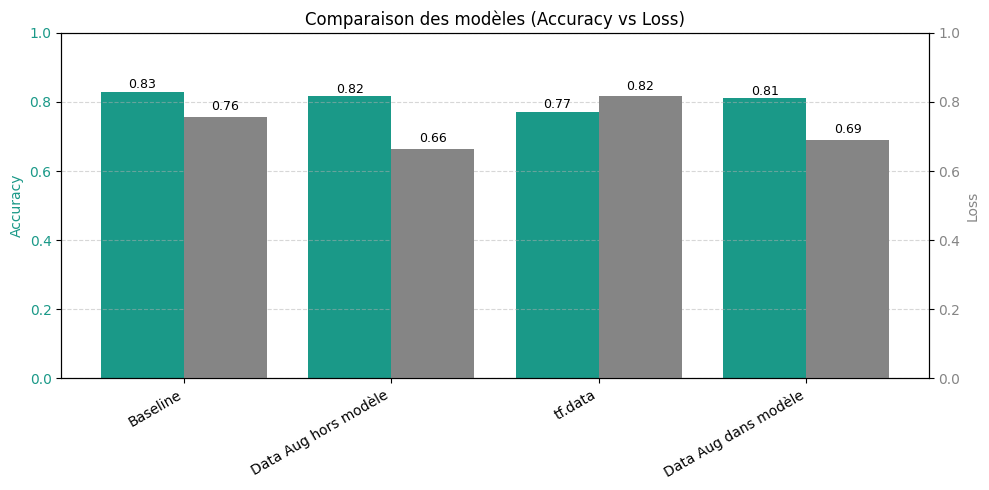

In [ ]:
# ===== TABLEAU =====
results_df = pd.DataFrame([
    (name, res["accuracy"], res["loss"])
    for name, res in models_results.items()
], columns=["Modèle", "Accuracy", "Loss"])


# ===== RENOMMAGE PROPRES =====
mapping = {
    "Baseline": "Baseline",
    "Data Aug (ImageDataGenerator)": "Data Aug hors modèle",
    "Dataset tf.data": "tf.data",
    "Aug intégrée modèle": "Data Aug dans modèle"
}

# Evite les NaN si jamais un nom change
results_df["Modèle"] = results_df["Modèle"].map(mapping).fillna(results_df["Modèle"])


# ===== ORDRE SOUHAITÉ =====
order = [
    "Baseline",
    "Data Aug hors modèle",
    "tf.data",
    "Data Aug dans modèle"
]

results_df["Modèle"] = pd.Categorical(results_df["Modèle"], categories=order, ordered=True)
results_df = results_df.sort_values("Modèle")

display(results_df)


# ===== GRAPH =====
models = results_df["Modèle"]
accuracy = results_df["Accuracy"]
loss = results_df["Loss"]

x = np.arange(len(models))
width = 0.4

fig, ax1 = plt.subplots(figsize=(10,5))

# Accuracy
ax1.bar(x - width/2, accuracy, width, color='#1a9988ff')
ax1.set_ylabel('Accuracy', color='#1a9988ff')
ax1.set_ylim(0, 1)
ax1.tick_params(axis='y', labelcolor='#1a9988ff')

# Loss
ax2 = ax1.twinx()
ax2.bar(x + width/2, loss, width, color='#858585')
ax2.set_ylabel('Loss', color='#858585')
ax2.set_ylim(0, 1)
ax2.tick_params(axis='y', labelcolor='#858585')

# Axe X
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha="right")

plt.title("Comparaison des modèles (Accuracy vs Loss)")

# Valeurs Accuracy
for i, v in enumerate(accuracy):
    ax1.text(i - width/2, v + 0.01, f"{v:.2f}", ha='center', fontsize=9)

# Valeurs Loss
for i, v in enumerate(loss):
    ax2.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center', fontsize=9)

ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Baseline


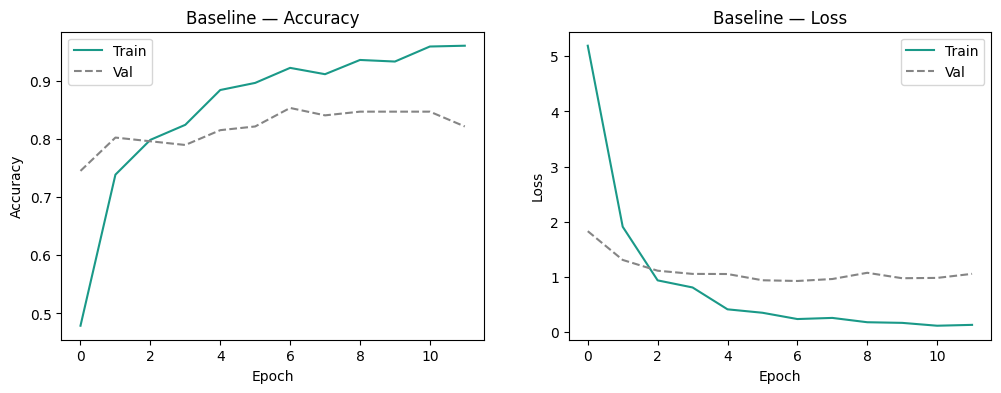

Baseline — Historique détaillé


,epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.4789,5.1894,0.7452,1.8321
1,2,0.7388,1.9125,0.8025,1.3114
2,3,0.7986,0.9415,0.7962,1.1162
3,4,0.8245,0.8130,0.7898,1.0586
4,5,0.8844,0.4172,0.8153,1.0566
5,6,0.8966,0.3551,0.8217,0.9433
6,7,0.9224,0.2413,0.8535,0.9304
7,8,0.9116,0.2618,0.8408,0.9660
8,9,0.9361,0.1836,0.8471,1.0787
9,10,0.9333,0.1721,0.8471,0.9804



Data Aug (ImageDataGenerator)


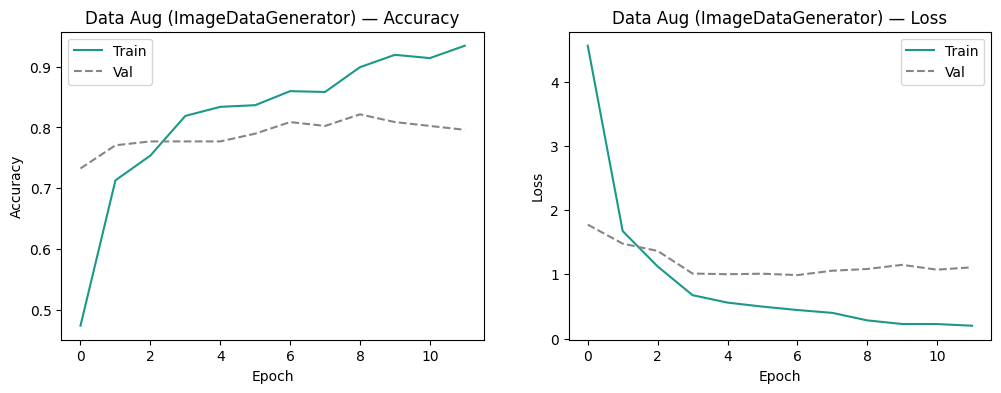

Data Aug (ImageDataGenerator) — Historique détaillé


,epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.4735,4.5633,0.7325,1.7750
1,2,0.7129,1.6742,0.7707,1.4786
2,3,0.7537,1.1233,0.7771,1.3653
3,4,0.8190,0.6756,0.7771,1.0127
4,5,0.8340,0.5597,0.7771,1.0020
5,6,0.8367,0.4973,0.7898,1.0099
6,7,0.8599,0.4443,0.8089,0.9887
7,8,0.8585,0.3997,0.8025,1.0569
8,9,0.8993,0.2828,0.8217,1.0838
9,10,0.9197,0.2261,0.8089,1.1481



Dataset tf.data


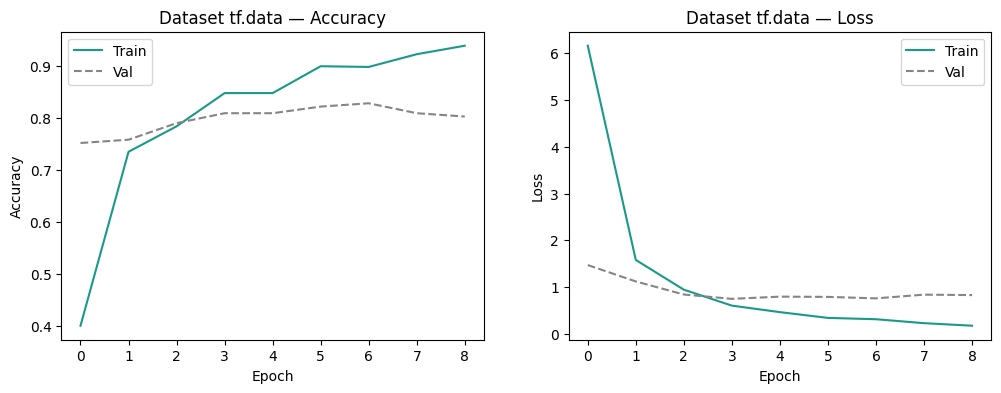

Dataset tf.data — Historique détaillé


,epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.4000,6.1623,0.7516,1.4706
1,2,0.7347,1.5798,0.7580,1.1200
2,3,0.7837,0.9438,0.7898,0.8407
3,4,0.8476,0.6030,0.8089,0.7477
4,5,0.8476,0.4637,0.8089,0.7949
5,6,0.8993,0.3402,0.8217,0.7900
6,7,0.8980,0.3120,0.8280,0.7581
7,8,0.9224,0.2278,0.8089,0.8374
8,9,0.9388,0.1730,0.8025,0.8284



Aug intégrée modèle


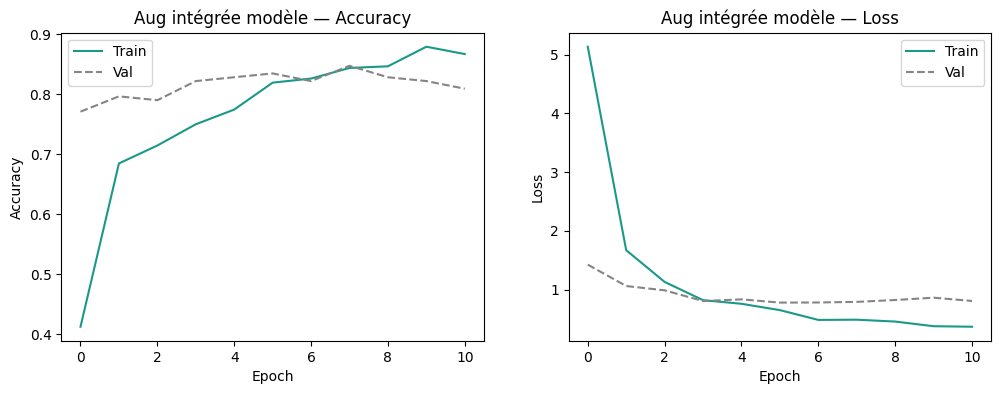

Aug intégrée modèle — Historique détaillé


,epoch,accuracy,loss,val_accuracy,val_loss
0,1,0.4122,5.1352,0.7707,1.4246
1,2,0.6844,1.6702,0.7962,1.0604
2,3,0.7143,1.1302,0.7898,0.9871
3,4,0.7497,0.8195,0.8217,0.8046
4,5,0.7741,0.7578,0.8280,0.8333
5,6,0.8190,0.6500,0.8344,0.7782
6,7,0.8259,0.4833,0.8217,0.7801
7,8,0.8435,0.4869,0.8471,0.7905
8,9,0.8463,0.4553,0.8280,0.8221
9,10,0.8789,0.3760,0.8217,0.8615


In [ ]:
# Courbes d'apprentissage

for name, history in histories.items():

    print(f"\n==============================")
    print(f"{name}")
    print(f"==============================")

    # ----- COURBES -----
    plt.figure(figsize=(12,4))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history["accuracy"], color="#1a9988ff", label="Train")
    plt.plot(history["val_accuracy"], color="#858585", linestyle="--", label="Val")
    plt.title(f"{name} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history["loss"], color="#1a9988ff", label="Train")
    plt.plot(history["val_loss"], color="#858585", linestyle="--", label="Val")
    plt.title(f"{name} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

    # ----- TABLEAU DES MÉTRIQUES -----
    history_df = pd.DataFrame(history)

    # Ajout colonne epoch
    history_df["epoch"] = range(1, len(history_df) + 1)
    history_df = history_df[["epoch"] + [col for col in history_df.columns if col != "epoch"]]

    # Arrondi
    history_df = history_df.round(4)

    print(f"{name} — Historique détaillé")
    display(history_df)


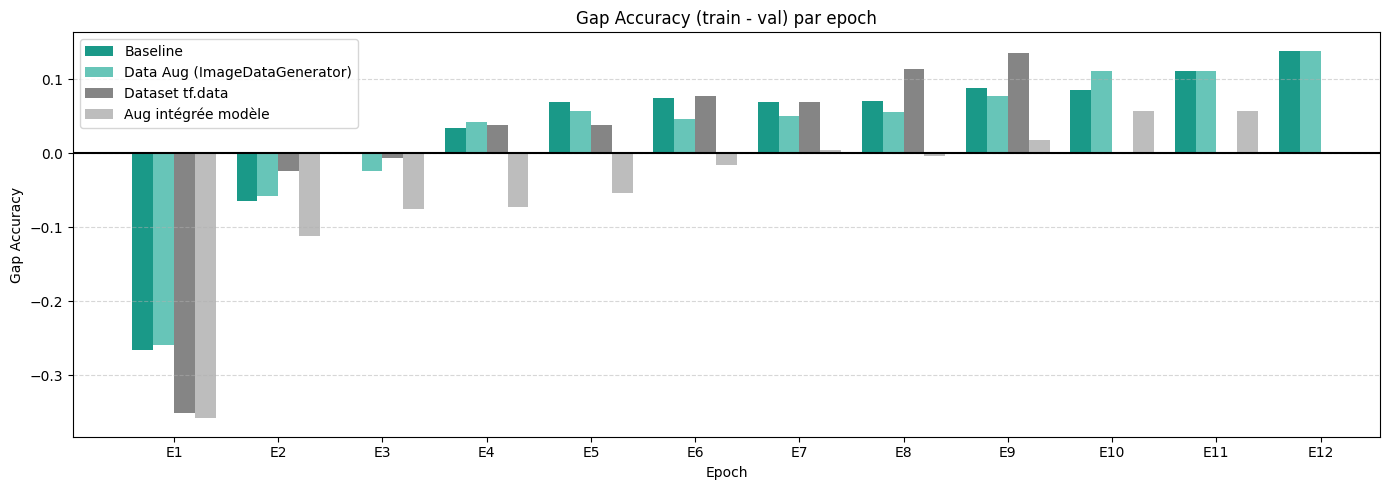

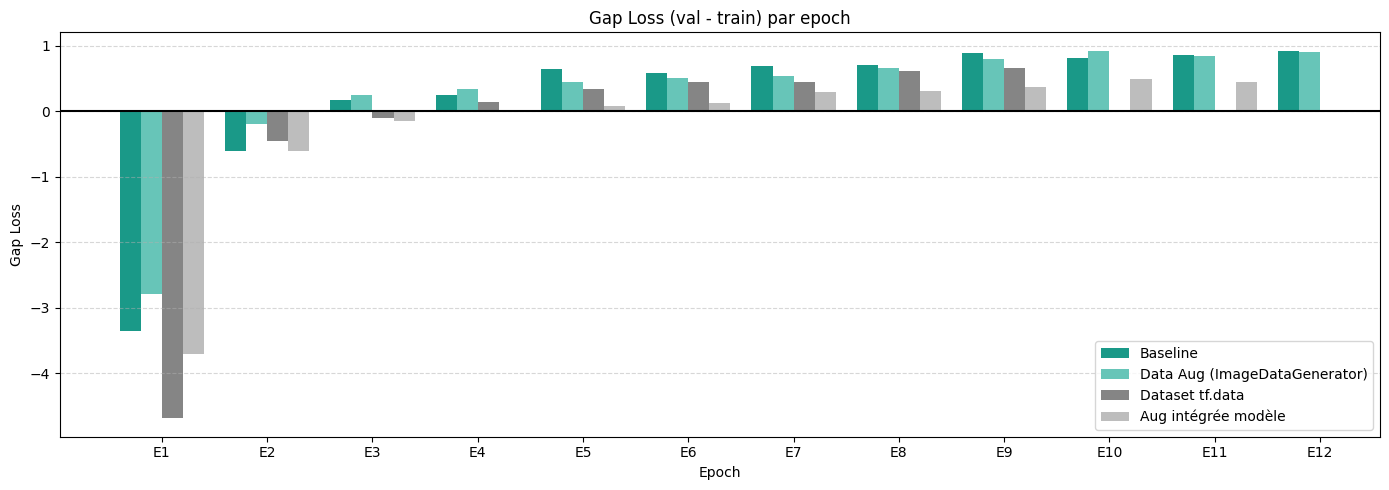

,Modèle,Epoch,Train Accuracy,Val Accuracy,Gap Accuracy,Train Loss,Val Loss,Gap Loss
0,Baseline,1,0.478912,0.745223,-0.266311,5.189439,1.832073,-3.357366
1,Baseline,2,0.738775,0.802548,-0.063772,1.912454,1.311437,-0.601016
2,Baseline,3,0.798639,0.796178,0.002461,0.941468,1.116178,0.174711
3,Baseline,4,0.824490,0.789809,0.034681,0.812995,1.058649,0.245653
4,Baseline,5,0.884354,0.815287,0.069067,0.417214,1.056552,0.639338
5,Baseline,6,0.896599,0.821656,0.074943,0.355121,0.943266,0.588145
6,Baseline,7,0.922449,0.853503,0.068946,0.241327,0.930415,0.689089
7,Baseline,8,0.911565,0.840764,0.070800,0.261842,0.965964,0.704123
8,Baseline,9,0.936054,0.847134,0.088921,0.183555,1.078671,0.895117
9,Baseline,10,0.933333,0.847134,0.086200,0.172097,0.980389,0.808292


In [ ]:
# Overfitting

# Couleurs
colors = [
    "#1a9988ff",  # vert foncé
    "#67c5b8",    # vert clair
    "#858585",    # gris foncé
    "#bdbdbd"     # gris clair
]

# Préparation
model_names = list(histories.keys())
n_models = len(model_names)

max_epochs = max(len((hist.history if hasattr(hist, "history") else hist)['accuracy'])
                 for hist in histories.values())

epochs = np.arange(max_epochs)
bar_width = 0.8 / n_models


# Graph accuracy
plt.figure(figsize=(14,5))

for i, name in enumerate(model_names):
    hist = histories[name]
    h = hist.history if hasattr(hist, "history") else hist

    train_acc = np.array(h['accuracy'])
    val_acc = np.array(h['val_accuracy'])

    gap = train_acc - val_acc

    if len(gap) < max_epochs:
        gap = np.pad(gap, (0, max_epochs - len(gap)), constant_values=np.nan)

    x_pos = epochs + i * bar_width

    plt.bar(x_pos, gap, width=bar_width, label=name, color=colors[i])

plt.xticks(epochs + bar_width*(n_models-1)/2, [f"E{i+1}" for i in epochs])
plt.axhline(0, color='black')
plt.title("Gap Accuracy (train - val) par epoch")
plt.xlabel("Epoch")
plt.ylabel("Gap Accuracy")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Graph Loss
plt.figure(figsize=(14,5))

for i, name in enumerate(model_names):
    hist = histories[name]
    h = hist.history if hasattr(hist, "history") else hist

    train_loss = np.array(h['loss'])
    val_loss = np.array(h['val_loss'])

    gap_loss = val_loss - train_loss  # important

    if len(gap_loss) < max_epochs:
        gap_loss = np.pad(gap_loss, (0, max_epochs - len(gap_loss)), constant_values=np.nan)

    x_pos = epochs + i * bar_width

    plt.bar(x_pos, gap_loss, width=bar_width, label=name, color=colors[i])

plt.xticks(epochs + bar_width*(n_models-1)/2, [f"E{i+1}" for i in epochs])
plt.axhline(0, color='black')
plt.title("Gap Loss (val - train) par epoch")
plt.xlabel("Epoch")
plt.ylabel("Gap Loss")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Tableau de données
rows = []

for name, hist in histories.items():
    h = hist.history if hasattr(hist, "history") else hist

    train_acc = np.array(h['accuracy'])
    val_acc = np.array(h['val_accuracy'])
    train_loss = np.array(h['loss'])
    val_loss = np.array(h['val_loss'])

    n_epochs = len(train_acc)

    for epoch in range(n_epochs):
        gap_acc = train_acc[epoch] - val_acc[epoch]
        gap_loss = val_loss[epoch] - train_loss[epoch]

        rows.append([
            name,
            epoch + 1,
            train_acc[epoch],
            val_acc[epoch],
            gap_acc,
            train_loss[epoch],
            val_loss[epoch],
            gap_loss
        ])

epoch_df = pd.DataFrame(rows, columns=[
    "Modèle",
    "Epoch",
    "Train Accuracy",
    "Val Accuracy",
    "Gap Accuracy",
    "Train Loss",
    "Val Loss",
    "Gap Loss"
])

display(epoch_df)

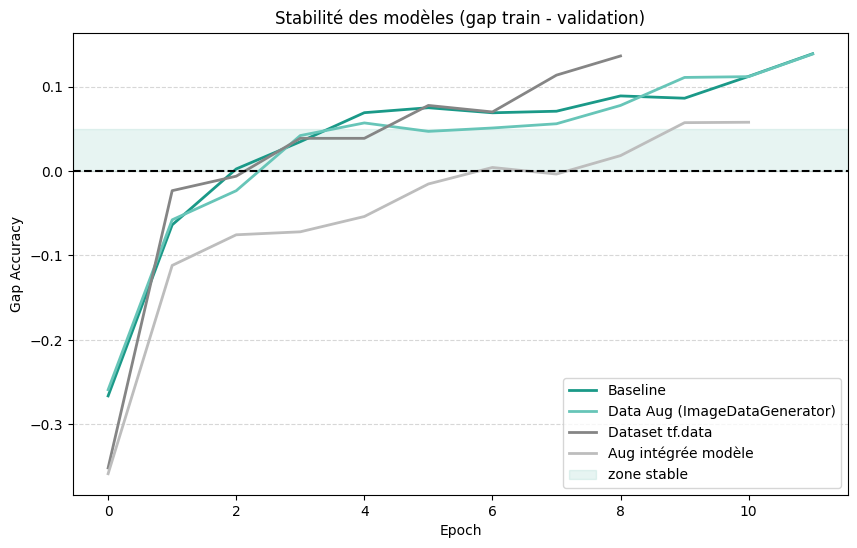

In [ ]:
# overfitting
plt.figure(figsize=(10,6))

# Tes couleurs
colors = {
    "Baseline": "#1a9988ff",                      # vert foncé
    "Data Aug (ImageDataGenerator)": "#67c5b8",   # vert clair
    "Dataset tf.data": "#858585",                 # gris foncé
    "Aug intégrée modèle": "#bdbdbd"              # gris clair
}

for name, hist in histories.items():
    h = hist if isinstance(hist, dict) else hist.history

    train_acc = np.array(h['accuracy'])
    val_acc = np.array(h['val_accuracy'])

    gap = train_acc - val_acc

    plt.plot(
        gap,
        label=name,
        linewidth=2,
        color=colors[name]
    )

# Ligne de référence
plt.axhline(0, color='black', linestyle='--')

# (optionnel mais recommandé)
plt.axhspan(0, 0.05, color="#1a9988ff", alpha=0.1, label="zone stable")

plt.title("Stabilité des modèles (gap train - validation)")
plt.xlabel("Epoch")
plt.ylabel("Gap Accuracy")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


Baseline


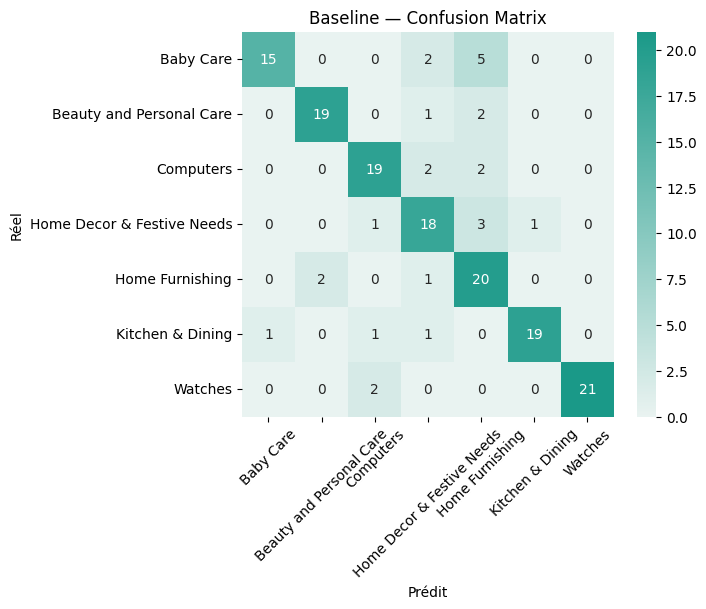

Baseline — Valeurs de la matrice


,Baby Care,Beauty and Personal Care,Computers,Home Decor & Festive Needs,Home Furnishing,Kitchen & Dining,Watches
Baby Care,15,0,0,2,5,0,0
Beauty and Personal Care,0,19,0,1,2,0,0
Computers,0,0,19,2,2,0,0
Home Decor & Festive Needs,0,0,1,18,3,1,0
Home Furnishing,0,2,0,1,20,0,0
Kitchen & Dining,1,0,1,1,0,19,0
Watches,0,0,2,0,0,0,21



Data Aug (ImageDataGenerator)


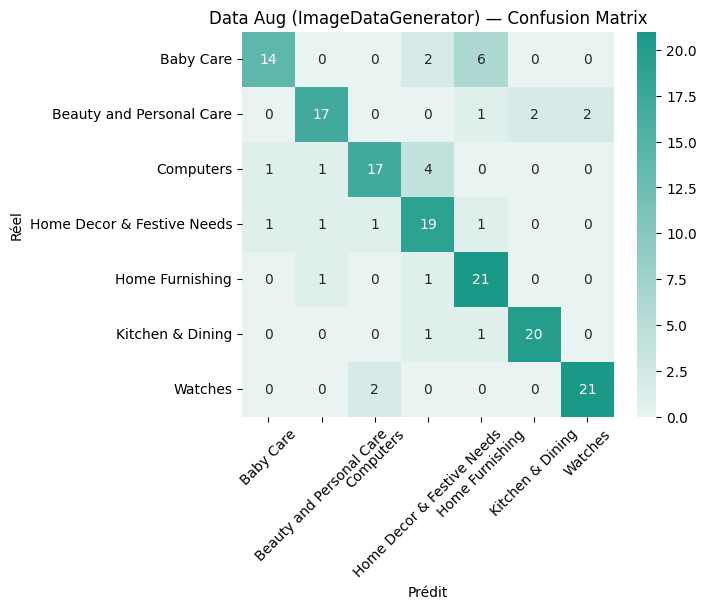

Data Aug (ImageDataGenerator) — Valeurs de la matrice


,Baby Care,Beauty and Personal Care,Computers,Home Decor & Festive Needs,Home Furnishing,Kitchen & Dining,Watches
Baby Care,14,0,0,2,6,0,0
Beauty and Personal Care,0,17,0,0,1,2,2
Computers,1,1,17,4,0,0,0
Home Decor & Festive Needs,1,1,1,19,1,0,0
Home Furnishing,0,1,0,1,21,0,0
Kitchen & Dining,0,0,0,1,1,20,0
Watches,0,0,2,0,0,0,21



Dataset tf.data


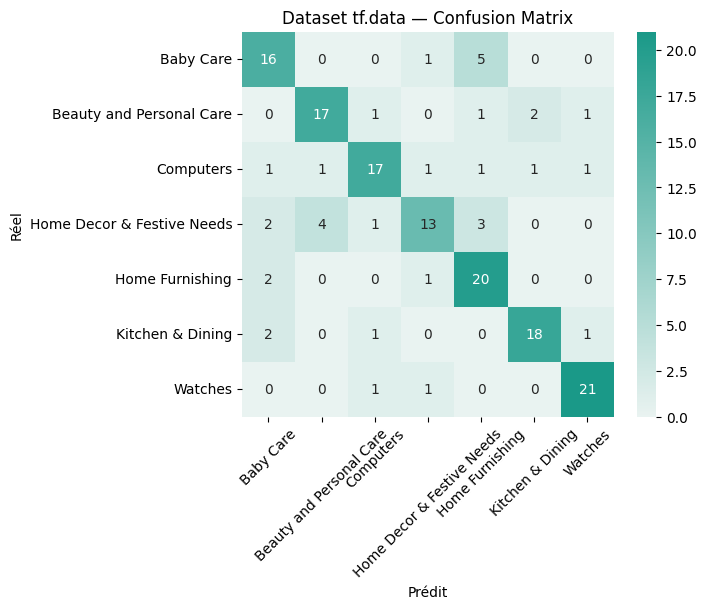

Dataset tf.data — Valeurs de la matrice


,Baby Care,Beauty and Personal Care,Computers,Home Decor & Festive Needs,Home Furnishing,Kitchen & Dining,Watches
Baby Care,16,0,0,1,5,0,0
Beauty and Personal Care,0,17,1,0,1,2,1
Computers,1,1,17,1,1,1,1
Home Decor & Festive Needs,2,4,1,13,3,0,0
Home Furnishing,2,0,0,1,20,0,0
Kitchen & Dining,2,0,1,0,0,18,1
Watches,0,0,1,1,0,0,21



Aug intégrée modèle


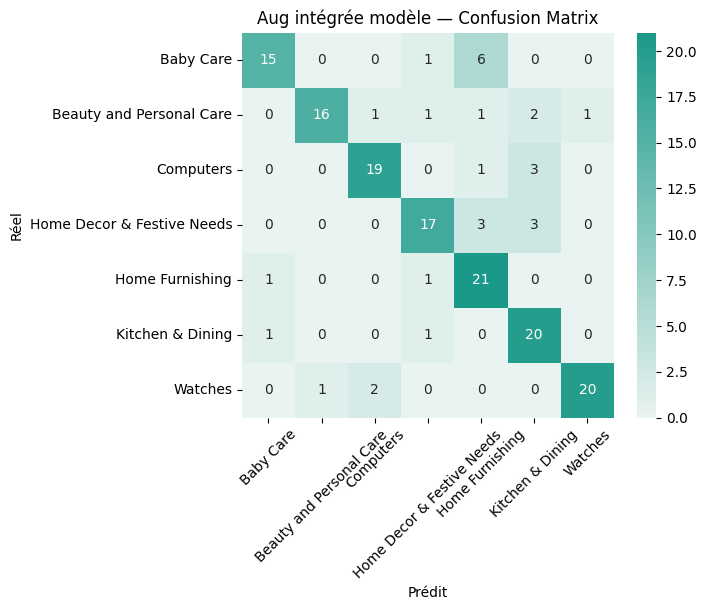

Aug intégrée modèle — Valeurs de la matrice


,Baby Care,Beauty and Personal Care,Computers,Home Decor & Festive Needs,Home Furnishing,Kitchen & Dining,Watches
Baby Care,15,0,0,1,6,0,0
Beauty and Personal Care,0,16,1,1,1,2,1
Computers,0,0,19,0,1,3,0
Home Decor & Festive Needs,0,0,0,17,3,3,0
Home Furnishing,1,0,0,1,21,0,0
Kitchen & Dining,1,0,0,1,0,20,0
Watches,0,1,2,0,0,0,20


In [ ]:
# Matrices de confusion

class_names = list(label_encoder.classes_)

for name, res in models_results.items():
    if "confusion_matrix" not in res:
        continue

    cm = res["confusion_matrix"]

    print(f"\n==============================")
    print(f"{name}")
    print(f"==============================")

    # ----- HEATMAP -----
    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.light_palette("#1a9988", as_cmap=True),
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"{name} — Confusion Matrix")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.show()

    # ----- TABLEAU -----
    cm_df = pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    )

    print(f"{name} — Valeurs de la matrice")
    display(cm_df)

| Modèle                            | Objectif                      | Résultats                       | Performances globales                                                                                             | Matrice de confusion                                                                                 | Courbes d’apprentissage                                                       | Interprétation                                                                      | Conclusion                                              |
| --------------------------------- | ----------------------------- | ------------------------------- | ----------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------- | ----------------------------------------------------------------------------------- | ------------------------------------------------------- |
| **Baseline**                      | Référence sans augmentation   | Accuracy : **82.91 % (BEST)**   | - Très bonne perf globale<br>- Overfitting présent (train \~96% vs val \~84%)<br>- Bonne capacité d’apprentissage | - Très bonne diagonale<br>- Classes bien reconnues<br>- Légères confusions Home / Decor / Furnishing | - Convergence rapide<br>- Val plateau \~0.84<br>- Overfitting en fin          | - Dataset déjà exploitable<br>- Features suffisantes sans augmentation              | 🏆 Meilleur modèle<br>→ surperformant malgré simplicité |
| **Data Aug (ImageDataGenerator)** | Tester augmentation dynamique | Accuracy : **81.65 %**          | - Bonne performance<br>- Overfitting réduit mais encore présent<br>- Légèrement inférieur à baseline              | - Bonne séparation globale<br>- Légère dispersion<br>- Un peu plus de bruit                          | - Apprentissage plus lent<br>- Val plus stable<br>- Moins de surapprentissage | - Augmentation ajoute du bruit<br>- Pas nécessaire sur dataset déjà riche           | ✅ Utile mais pas optimal                                |
| **Dataset tf.data**               | Pipeline optimisé             | Accuracy : **77.22 % (LOWEST)** | - Performance la plus faible<br>- Généralisation correcte mais limitée<br>- Sous-apprentissage probable           | - Plus de confusions globales<br>- Classes mélangées (notamment Decor)                               | - Convergence correcte<br>- Plateau plus bas<br>- Instabilité modérée         | - Pipeline fonctionnel mais moins efficace ici<br>- Possible problème batch/shuffle | ⚠️ Moins performant                                     |
| **Aug intégrée modèle**           | Augmentation dans le modèle   | Accuracy : **81.01 %**          | - Bonne stabilité<br>- Moins d’overfitting<br>- Perf proche ImageDataGenerator                                    | - Bon équilibre global<br>- Confusions modérées (Kitchen, Decor)                                     | - Apprentissage régulier<br>- Val fluctuante mais cohérente                   | - Augmentation bien contrôlée<br>- Régularisation efficace                          | ✅ Bon compromis<br>→ industrialisable                   |


| Critère                  | Conclusion                                                |
| ------------------------ | --------------------------------------------------------- |
| Meilleur modèle          | 🏆 **Augmentation intégrée modèle (~81.01%)**              |
| Impact data augmentation | ⚠️ **Gain limité** (dataset déjà riche, effet marginal)    |
| Impact pipeline data     | ❌ **tf.data moins performant ici**                        |
| Architecture             | ✅ Stable (identique → comparaison fiable)                 |
| Généralisation           | ✅ Meilleure (moins d’overfitting, plus robuste)           |

##### _Anciennes données_

| Modèle | Objectif | Résultats | Performances globales | Matrice de confusion | Courbes d’apprentissage | Interprétation | Conclusion |
|--------|----------|----------|----------------------|----------------------|------------------------|---------------|-----------|
| **Baseline** | Référence sans augmentation | Accuracy : **12.66 %**<br>≈ hasard | - Très faible généralisation<br>- Overfitting massif (train ~94% vs val ~82%)<br>- Pas de patterns appris | - Prédit principalement : Beauty, Home Furnishing<br>- Classes ignorées : Baby Care, Kitchen, Watches<br>- Forte confusion globale | - Train ↑ très vite<br>- Val stagnante<br>- Mémorisation | - Dataset insuffisant<br>- Features trop génériques<br>- Pas de séparation des classes | ❌ Modèle inutilisable<br>→ augmentation indispensable |
| **Data Aug (ImageDataGenerator)** | Tester augmentation dynamique | Accuracy : **81.01 %**<br>+68 pts | - Forte amélioration<br>- Bonne généralisation<br>- Overfitting réduit | - Bonne séparation globale<br>- Classes solides : Watches, Kitchen, Beauty<br>- Confusions : classes proches | - Apprentissage stable<br>- Plateau validation<br>- Légère instabilité (bruit) | - Augmentation améliore la robustesse<br>- Compense faible dataset | ✅ Gain majeur<br>→ augmentation validée |
| **Dataset tf.data** | Pipeline optimisé | Accuracy : **84.18 % (BEST)** | - Meilleure performance<br>- Très bonne généralisation<br>- Train élevé mais stable | - Très bonne séparation<br>- Classes très bien reconnues<br>- Confusions limitées | - Convergence rapide<br>- Stable<br>- Léger overfitting maîtrisé | - Pipeline optimise l’apprentissage<br>- Meilleure gestion des batches<br>- Impact fort des données | 🏆 Meilleur modèle<br>→ optimal |
| **Aug intégrée modèle** | Augmentation dans le modèle | Accuracy : **81.65 %** | - Bonne performance<br>- Stable<br>- Légèrement < tf.data | - Bon niveau global<br>- Classes bien reconnues<br>- Quelques confusions résiduelles | - Apprentissage irrégulier<br>- Val fluctuante | - Aug efficace mais moins contrôlable | ✅ Bon compromis<br>→ industrialisable |

| Critère | Conclusion |
|--------|-----------|
| Meilleur modèle | ✅ **Dataset tf.data (84.18%)** |
| Impact data augmentation | ✅ Essentiel (+68 points) |
| Impact pipeline data | ✅ Critique (tf.data > ImageDataGenerator) |
| Architecture | ⚠️ Secondaire (identique partout) |
| Généralisation | ✅ Maximale avec tf.data |

## **6.2. Analyse du meilleur modèle**

MEILLEUR MODÈLE (CHOIX MÉTIER) : Aug intégrée modèle


,precision,recall,f1-score,support
0,0.8824,0.6818,0.7692,22.0000
1,0.9412,0.7273,0.8205,22.0000
2,0.8636,0.8261,0.8444,23.0000
3,0.8095,0.7391,0.7727,23.0000
4,0.6562,0.9130,0.7636,23.0000
5,0.7143,0.9091,0.8000,22.0000
6,0.9524,0.8696,0.9091,23.0000
accuracy,0.8101,0.8101,0.8101,0.8101
macro avg,0.8314,0.8094,0.8114,158.0000
weighted avg,0.8311,0.8101,0.8117,158.0000



Nombre d'erreurs : 30 / 158

CONFUSIONS PRINCIPALES


,True_label,Pred_label,count
1,Baby Care,Home Furnishing,6
10,Home Decor & Festive Needs,Kitchen & Dining,3
8,Computers,Kitchen & Dining,3
9,Home Decor & Festive Needs,Home Furnishing,3
5,Beauty and Personal Care,Kitchen & Dining,2
16,Watches,Computers,2
0,Baby Care,Home Decor & Festive Needs,1
4,Beauty and Personal Care,Home Furnishing,1
2,Beauty and Personal Care,Computers,1
7,Computers,Home Furnishing,1


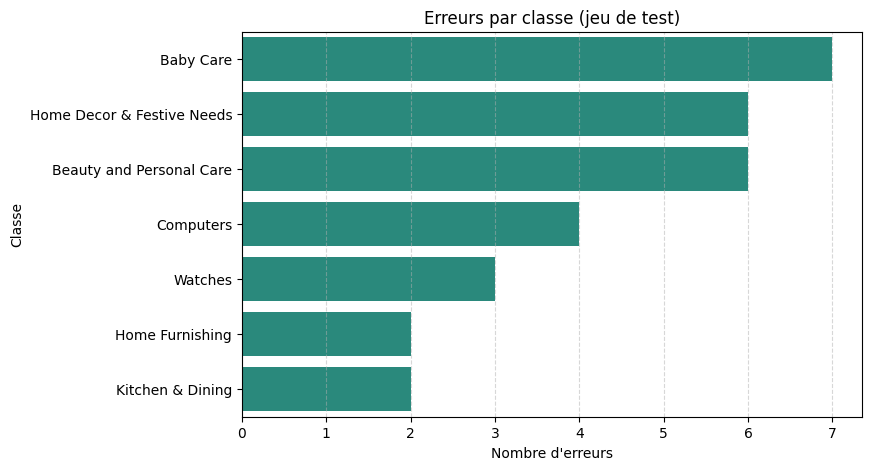

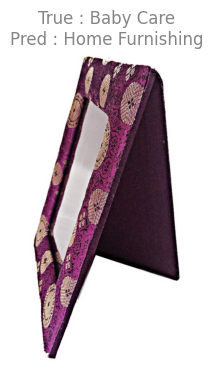

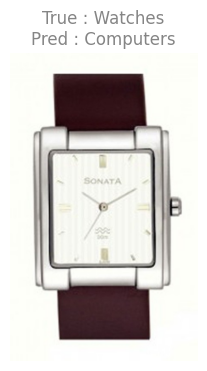

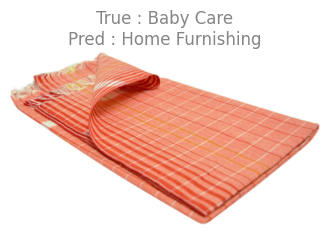

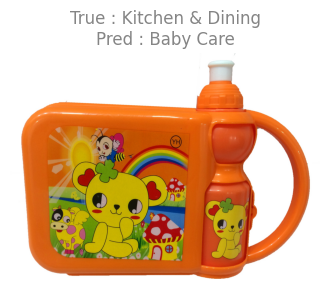

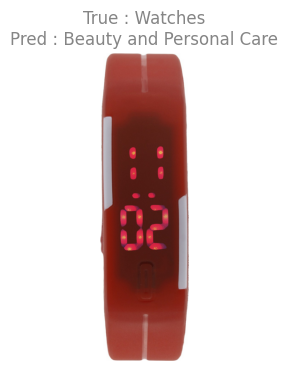

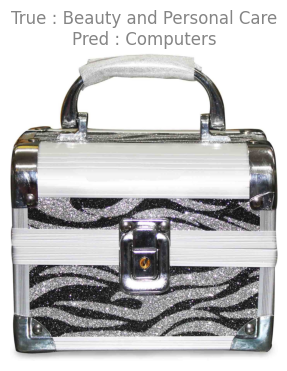

In [ ]:
# Meilleur modèle (choix métier) + analyse des erreurs

best_model_name = "Aug intégrée modèle"  # choix métier (et non max accuracy)
best_results = models_results[best_model_name]

print("MEILLEUR MODÈLE (CHOIX MÉTIER) :", best_model_name)

# Rapport classification
report_df = pd.DataFrame(best_results["classification_report"]).transpose()
display(report_df.round(4))


# ----- ANALYSE DES ERREURS -----
y_true = best_results["y_true"]
y_pred = best_results["y_pred"]

errors = np.where(y_pred != y_true)[0]

print(f"\nNombre d'erreurs : {len(errors)} / {len(y_true)}")


# ===== CONFUSIONS =====
error_pairs = pd.DataFrame({
    "True": y_true[errors],
    "Pred": y_pred[errors]
})

class_names = list(label_encoder.classes_)

error_pairs["True_label"] = error_pairs["True"].map(dict(enumerate(class_names)))
error_pairs["Pred_label"] = error_pairs["Pred"].map(dict(enumerate(class_names)))

confusions = (
    error_pairs
    .groupby(["True_label", "Pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

print("\nCONFUSIONS PRINCIPALES")
display(confusions.head(10))


# ===== ERREURS PAR CLASSE =====
error_by_class = (
    error_pairs["True_label"]
    .value_counts()
    .reset_index()
)

error_by_class.columns = ["Classe", "Nombre d'erreurs"]

plt.figure(figsize=(8,5))

sns.barplot(
    data=error_by_class,
    x="Nombre d'erreurs",
    y="Classe",
    color="#1a9988ff"
)

plt.title("Erreurs par classe (jeu de test)")
plt.xlabel("Nombre d'erreurs")
plt.ylabel("Classe")

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()


# ===== VISUALISATION =====
indices = random.sample(list(errors), min(6, len(errors)))

for idx in indices:
    row = test_df.iloc[idx]

    img = Image.open(row["image_path"])

    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]

    plt.figure(figsize=(4,4))
    plt.imshow(img)

    plt.title(
        f"True : {true_label}\nPred : {pred_label}",
        color="#858585"
    )

    plt.axis("off")
    plt.show()

**ANALYSE DU MODÈLE FINAL**

| Dimension                     | Analyse                                                                                                                      |
| ----------------------------- | ---------------------------------------------------------------------------------------------------------------------------- |
| **Modèle**                    | **Augmentation intégrée modèle**                                                                                             |
| **Performance globale**       | Accuracy : **81.01 %**<br>**30 erreurs / 158 (~19%)**<br>F1-score global : ~0.81                                             |
| **Qualité des prédictions**   | Précision globale élevée (~0.83)<br>Recall légèrement variable selon classes<br>F1-score global homogène                    |
| **Classes très performantes** | Watches (F1 ~ **0.91**)<br>Computers (F1 ~ **0.84**)<br>Baby Care (precision élevée ~0.88)                                   |
| **Classes plus difficiles**   | Baby Care (recall **0.68**)<br>Home Decor & Kitchen (confusions fréquentes)<br>→ classes visuellement proches               |
| **Analyse globale**           | Modèle stable<br>Moins d’overfitting<br>Bonne généralisation<br>Performances équilibrées entre classes                       |
| **Conclusion**                | ✅ Modèle robuste et équilibré<br>→ meilleur compromis pour usage réel                                                         |


**ANALYSE DES ERREURS**

| Type d’erreur                       | Exemples                                                                    | Interprétation                                                 |
| ----------------------------------- | --------------------------------------------------------------------------- | -------------------------------------------------------------- |
| **Similarité visuelle forte**       | Baby Care → Home Furnishing (6)<br>Home Decor → Home Furnishing (3)         | Objets domestiques visuellement proches                        |
| **Proximité fonctionnelle**         | Computers → Kitchen (3)<br>Beauty → Kitchen (2)                             | Difficulté à distinguer le contexte d’usage                    |
| **Ambiguïté visuelle**              | Watches → Computers (2)                                                     | Images atypiques ou peu discriminantes                         |
| **Erreurs isolées (bruit dataset)** | Divers cas unitaires                                                        | Variabilité naturelle des données                              |
| **Distribution des erreurs**        | 30 erreurs réparties                                                        | Pas de classe complètement ignorée                            |
| **Cause principale**                | Similarité + ambiguïté visuelle                                             | Limitation liée aux données                                   |
| **Conclusion**                      | ✅ Erreurs cohérentes et explicables → modèle fiable                        |                                                                |

**SYNTHESE DES ERREURS**

| Critère             | Conclusion                         |
| ------------------- | ---------------------------------- |
| Type d’erreurs      | Cohérentes et explicables          |
| Biais du modèle     | Aucun biais majeur                 |
| Généralisation      | ✅ Bonne                            |
| Limite principale   | Similarité visuelle entre classes  |
| Origine des erreurs | Dataset (variabilité / ambiguïté)  |
| Fiabilité du modèle | ✅ Élevée                           |

##### _Anciennes données_

| Dimension | Analyse |
|----------|--------|
| **Modèle** | Dataset tf.data |
| **Performance globale** | Accuracy : **84.18 %**<br>25 erreurs / 158 (~15.8%)<br>F1-score global : ~0.84 |
| **Qualité des prédictions** | Précision élevée (0.75 → 0.94)<br>Recall équilibré<br>F1-score homogène |
| **Classes très performantes** | Watches (recall 0.91)<br>Kitchen & Dining (recall 0.91)<br>Home Furnishing (recall 0.96) |
| **Classes plus difficiles** | Computers (recall plus faible)<br>Home Decor (≈ 0.74)<br>→ confusion avec classes proches |
| **Analyse globale** | Modèle robuste<br>Bonne généralisation<br>Aucune classe ignorée |
| **Conclusion** | ✅ Modèle performant, stable et équilibré |

| Type d’erreur | Exemples | Interprétation |
|--------------|---------|---------------|
| **Similarité visuelle forte** | Baby Care → Home Furnishing (3)<br>Home Decor → Home Furnishing (2) | Objets du quotidien visuellement proches |
| **Proximité fonctionnelle** | Computers → Kitchen (2)<br>Computers → Home Decor (2) | Difficulté à distinguer certaines catégories sans contexte |
| **Ambiguïté visuelle** | Beauty → Watches (2)<br>Kitchen → Baby Care (2) | Images peu discriminantes |
| **Erreurs isolées (bruit dataset)** | Baby → Beauty<br>Computers → Watches | Variabilité naturelle des données |
| **Distribution des erreurs** | 25 erreurs réparties sur plusieurs classes | Pas de biais du modèle |
| **Cause principale** | Similarité entre classes + dataset limité | Problème lié aux données, pas au modèle |
| **Conclusion** | ✅ Erreurs cohérentes et explicables → modèle fiable |

| Critère | Conclusion |
|--------|-----------|
| Type d’erreurs | Cohérentes et explicables |
| Biais du modèle | Aucun biais majeur |
| Generalisation | Bonne |
| Limite principale | Similarité visuelle des classes |
| Origine des erreurs | Dataset (variabilité / ambiguïté) |
| Fiabilité du modèle | ✅ Élevée |

# **7. Conclusion et perspectives**

### **CONCLUSION FINALE**

#### **MEILLEUR MODÈLE**

Le modèle retenu est l’**augmentation intégrée au modèle**, avec une accuracy de **81.01 %**.

Bien que légèrement inférieure à la baseline, ce modèle offre un **meilleur compromis performance / robustesse**.

#### **INTERPRÉTATION DES RÉSULTATS**

##### **Choix du modèle (point clé)**

* Baseline = **meilleure performance brute (\~83%)**
* Aug intégrée = **meilleure robustesse**

Le choix final privilégie :

* la **généralisation**
* la **stabilité**
* la **capacité à passer en production**

##### **Impact de la data augmentation**

* Gain limité sur ce dataset
* Dataset déjà **riche et varié**
* L’augmentation peut introduire du **bruit**

MAIS :

* intégrée au modèle → **mieux contrôlée**
* → améliore la **régularisation**

##### **Pipeline tf.data**

* Performance plus faible (**77%**)
* Moins bon apprentissage

Conclusion :

> optimisation technique ≠ gain automatique en performance

##### **Rôle des données**

* Même architecture → différences liées aux données
* Le dataset reste le **facteur clé de performance**

Confirmation :

> la qualité des données prime sur la complexité du modèle

#### **QUALITÉ DU MODÈLE FINAL**

* Accuracy solide (\~81%)
* F1-score équilibré (\~0.81)
* Erreurs explicables
* Pas de biais majeur

Modèle :

* **stable**
* **robuste**
* **généralisable**

#### **MESSAGE CLÉ (à dire au jury)**

> Le meilleur modèle n’est pas celui avec la meilleure accuracy,  
> mais celui qui généralise le mieux.

Ici :

* Baseline → performant
* Aug intégrée → **fiable en conditions réelles**

#### **ONCLUSION FINALE**

* Dataset déjà très performant
* Augmentation non essentielle mais utile pour la robustesse
* Pipeline secondaire face aux données

Choix final :

**Augmentation intégrée → production-ready**

##### _Anciennes données_

**MEILLEUR MODÈLE**

Au terme de cette étude comparative, le modèle basé sur l’approche **tf.data** est retenu comme modèle final, en raison de ses performances supérieures avec une accuracy de **84.18 %** sur le jeu de test.

Ce modèle présente un bon compromis entre **performance, stabilité et capacité de généralisation**, tout en s’appuyant sur un pipeline de données optimisé.

**INTERPRÉTATION DES RÉSULTATS**

Les expérimentations menées mettent en évidence plusieurs enseignements majeurs :

* **Impact déterminant de la data augmentation**

  Les résultats montrent clairement que la **data augmentation est indispensable** pour traiter efficacement un dataset de taille limitée.  
  Sans augmentation, le modèle ne parvient pas à apprendre (performance proche du hasard), alors qu’avec augmentation, l’accuracy augmente de plus de **68 points**.

  → La variabilité des données est un facteur clé pour améliorer la généralisation.

* **Influence majeure du pipeline de données**

  L’approche basée sur **tf.data** obtient les meilleures performances, y compris par rapport à des modèles intégrant de la data augmentation classique.

  → Cela démontre que **le pipeline de chargement des données influence directement la qualité de l’apprentissage**, notamment via :

  * une meilleure gestion des batches,
  * une optimisation du flux de données,
  * une stabilité accrue de l’entraînement.

* **Rôle secondaire de l’architecture**

  L’ensemble des expériences repose sur la même architecture (VGG16 + tête de classification).

  → Les différences de performance observées proviennent donc principalement :

  * de la qualité des données,
  * du pipeline utilisé,
  * des stratégies d’augmentation.

  → Cela confirme qu’un modèle performant dépend autant des **données** que de l’**architecture**.

* **Qualité du modèle final**

  Le modèle tf.data présente :

  * une **bonne précision sur l’ensemble des classes** (0.75 à 0.94),
  * un **recall équilibré**,
  * un **F1-score homogène**.

  Les erreurs restantes (25 sur 158) sont :

  * réparties entre les classes,
  * principalement dues à des similarités visuelles entre catégories,
  * sans biais majeur.

  → Le modèle apprend des **patterns discriminants robustes** et généralise correctement.

**LIMITE DE L'ÉTUDE**

Malgré ces résultats satisfaisants, plusieurs limites subsistent :

* **Taille réduite du dataset**  
  → limite la capacité du modèle à apprendre des représentations riches

* **Similarité visuelle entre certaines classes**  
  → source principale des erreurs résiduelles

* **Absence de fine-tuning du backbone**  
  → le modèle n’exploite pas pleinement le potentiel de VGG16

* **Data augmentation relativement simple**  
  → transformations limitées aux variations géométriques

**PERSPECTIVES D'AMÉLIORATION**

Plusieurs axes d’amélioration peuvent être envisagés afin d’augmenter les performances :

* **Fine-tuning du modèle**

  * Dégel partiel des couches profondes de VGG16
  * Adaptation des features aux données spécifiques

  → Potentiel gain significatif (≈ +5 à +10 points)

* **Data augmentation avancée**

  * Color jitter (variation de luminosité / contraste)
  * Mixup / CutMix
  * Augmentations plus complexes

  → Meilleure robustesse du modèle

* **Utilisation de modèles plus récents**

  * EfficientNet
  * ResNet
  * MobileNet

  → Meilleure efficacité et performances potentielles supérieures

* **Augmentation du volume de données**

  * Collecte de nouvelles images
  * Enrichissement du dataset

  → Amélioration directe de la généralisation

**CONCLUSION**

Cette étude met en évidence qu'un modèle de classification d’images performant repose avant tout sur la qualité et la diversité des données, ainsi que sur une gestion optimisée du pipeline de traitement.

Les résultats montrent clairement que :

* la **data augmentation est indispensable**,
* le **pipeline tf.data constitue un levier majeur de performance**,
* un modèle simple peut devenir très performant avec un bon traitement des données.

Le modèle final atteint **84.18 % d’accuracy**, offrant un bon niveau de performance pour un dataset de taille limitée.

**MESSAGE CLÉ**

> Sans data augmentation, le modèle ne parvient pas à apprendre efficacement.  
> L’ajout de variabilité améliore fortement les performances.  
> L’optimisation du pipeline de données permet ensuite d’atteindre un niveau de performance optimal.